In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,TargetEncoder
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
df_train = pd.read_csv("/content/used_car_train.csv", index_col='id')

In [ ]:
Q1 = df_train['price'].quantile(0.25)
Q3 = df_train['price'].quantile(0.75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5*IQR

outlier_id = df_train[df_train['price']> upper_whisker].index
outlier_id_1 = df_train[df_train['price']>500_000].index
outlier_id_2 = df_train[df_train['price']>1_000_000].index

df_outlier =df_train.loc[outlier_id]


df_outlier_1 = df_outlier[(df_outlier['price'] > upper_whisker) & (df_outlier['price'] < 500_000)]
df_outlier_2 = df_outlier[(df_outlier['price'] > 500_000) & (df_outlier['price'] < 1_000_000)]
df_outlier_3 = df_outlier[(df_outlier['price'] > 1_500_000) & (df_outlier['price'] < 2_000_000)]
df_outlier_4 = df_outlier[df_outlier['price'] > 2_500_000]


df_non_outlier = df_train.loc[~df_train.index.isin(outlier_id)]
df_non_outlier_1 = df_train.loc[~df_train.index.isin(outlier_id_1)]
df_non_outlier_2 = df_train.loc[~df_train.index.isin(outlier_id_2)]

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188533 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188533 non-null  object
 1   model         188533 non-null  object
 2   model_year    188533 non-null  int64 
 3   milage        188533 non-null  int64 
 4   fuel_type     183450 non-null  object
 5   engine        188533 non-null  object
 6   transmission  188533 non-null  object
 7   ext_col       188533 non-null  object
 8   int_col       188533 non-null  object
 9   accident      186081 non-null  object
 10  clean_title   167114 non-null  object
 11  price         188533 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 22.7+ MB


In [ ]:
outlier_id

Index([    31,     36,     43,     44,     65,    155,    217,    218,    220,
          251,
       ...
       188388, 188401, 188416, 188452, 188455, 188463, 188469, 188476, 188485,
       188501],
      dtype='int64', name='id', length=10880)

In [ ]:
df_non_outlier.info()

<class 'pandas.core.frame.DataFrame'>
Index: 177653 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         177653 non-null  object
 1   model         177653 non-null  object
 2   model_year    177653 non-null  int64 
 3   milage        177653 non-null  int64 
 4   fuel_type     172978 non-null  object
 5   engine        177653 non-null  object
 6   transmission  177653 non-null  object
 7   ext_col       177653 non-null  object
 8   int_col       177653 non-null  object
 9   accident      175417 non-null  object
 10  clean_title   158778 non-null  object
 11  price         177653 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 17.6+ MB


In [ ]:
df_non_outlier_1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188181 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188181 non-null  object
 1   model         188181 non-null  object
 2   model_year    188181 non-null  int64 
 3   milage        188181 non-null  int64 
 4   fuel_type     183110 non-null  object
 5   engine        188181 non-null  object
 6   transmission  188181 non-null  object
 7   ext_col       188181 non-null  object
 8   int_col       188181 non-null  object
 9   accident      185737 non-null  object
 10  clean_title   166816 non-null  object
 11  price         188181 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 18.7+ MB


In [ ]:
df_non_outlier_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188385 entries, 0 to 188532
Data columns (total 12 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188385 non-null  object
 1   model         188385 non-null  object
 2   model_year    188385 non-null  int64 
 3   milage        188385 non-null  int64 
 4   fuel_type     183304 non-null  object
 5   engine        188385 non-null  object
 6   transmission  188385 non-null  object
 7   ext_col       188385 non-null  object
 8   int_col       188385 non-null  object
 9   accident      185937 non-null  object
 10  clean_title   166986 non-null  object
 11  price         188385 non-null  int64 
dtypes: int64(3), object(9)
memory usage: 18.7+ MB


# Data Preprocessing

## Splitting Input and output

In [ ]:
def split_input_output(data, target_col = 'price'):
  X = data.drop(target_col, axis = 1)
  y = data[target_col]
  print("X shape: " +str(X.shape))
  print("y shape: " + str(y.shape))
  return X, y

In [ ]:
X_train, y_train = split_input_output(df_non_outlier_2, 'price')

X shape: (188385, 11)
y shape: (188385,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188385 entries, 0 to 188532
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188385 non-null  object
 1   model         188385 non-null  object
 2   model_year    188385 non-null  int64 
 3   milage        188385 non-null  int64 
 4   fuel_type     183304 non-null  object
 5   engine        188385 non-null  object
 6   transmission  188385 non-null  object
 7   ext_col       188385 non-null  object
 8   int_col       188385 non-null  object
 9   accident      185937 non-null  object
 10  clean_title   166986 non-null  object
dtypes: int64(2), object(9)
memory usage: 17.2+ MB


## Handling Inconsistent format: fuel_type and transmission

In [ ]:
def format_cleaning(X):
  X = X.copy()

  #Handling Inconsistencies in 'fuel_type'
  X['fuel_type'] = X['fuel_type'].replace({'–': 'Unknown','not supported': 'Other', np.nan: 'Unknown'})

  #Handling Inconsistencies in 'Transmission'
  trans_series = X['transmission'].astype(str).str.lower().str.strip()
  X['transmission'] = "Unknown"
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"

  return X

In [ ]:
X_train_format_cleaning = format_cleaning(X_train)

/tmp/ipython-input-288801657.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
/tmp/ipython-input-288801657.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"


## Extracting Information from `engine`

In [ ]:
def extract_fuel(val):
    s = str(val).lower()

    if "hydrogen"in s:
        return "Hydrogen"
    elif "electric" in s:
        return "Electric"
    elif "plug-in hybrid" in s:
        return "Plug-In Hybrid"
    elif "hybrid" in s:
        return "Hybrid"
    elif "diesel" in s:
        return "Diesel"
    elif "gasoline" in s:
        return "Gasoline"
    elif "flexible fuel" in s or "flex fuel" in s:
        return "Flexible Fuel"
    else:
        return "Unknown"

def extract_horsepower(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'([\d.]+)\s*HP', val, re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def extract_engine_size(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'([\d.]+)\s*L', val, re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

def extract_cylinder(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'\bV?(\d+)\s*(Cylinder|V\d|I\d|Rotary)', val, re.IGNORECASE)
    return int(match.group(1)) if match else np.nan

def extract_is_electric(val):
    if not isinstance(val, str):
        return 0
    return 1 if re.search(r'electric\s+motor', val, re.IGNORECASE) else 0

def extract_is_turbo(val):
    if not isinstance(val, str):
        return 0
    return 1 if re.search(r'turbo|supercharged', val, re.IGNORECASE) else 0

def extract_fuel_system(val):
    if not isinstance(val, str):
        return np.nan
    match = re.search(r'([A-Za-z\s]+Fuel\s*System|[A-Za-z\s]+Fuel)$', val.strip(), re.IGNORECASE)
    return match.group(1).strip() if match else "Unknown"

In [ ]:
def extract_info(X, engine_col="engine"):
  X = X.copy()
  specs_df = pd.DataFrame({
        "horsepower": X[engine_col].apply(extract_horsepower),
        "engine_size": X[engine_col].apply(extract_engine_size),
        "cylinder": X[engine_col].apply(extract_cylinder),
        "is_electric": X[engine_col].apply(extract_is_electric),
        "is_turbo": X[engine_col].apply(extract_is_turbo),
        "fuel_system": X[engine_col].apply(extract_fuel_system),
    })

  fuel = X['engine'].apply(extract_fuel)
  X['fuel_type'] = X['fuel_type'].mask(X['fuel_type'] == "Unknown", fuel)

    # Set 0 untuk EV jika hp/cylinder/size NaN
  mask_ev = specs_df["is_electric"] == 1
  specs_df.loc[mask_ev & specs_df["horsepower"].isna(), "horsepower"] = 0
  specs_df.loc[mask_ev & specs_df["cylinder"].isna(), "cylinder"] = 0
  specs_df.loc[mask_ev & specs_df["engine_size"].isna(), "engine_size"] = 0

  X.drop(['engine'], axis = 1,inplace=True)

  return pd.concat([X, specs_df], axis=1)

In [ ]:
X_train_extracted = extract_info(X_train_format_cleaning)

## Handling Missing Values: `accident` and `clean_title`

In [ ]:
X_train_extracted.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
transmission,0
ext_col,0
int_col,0
accident,2448
clean_title,21399


In [ ]:
#impute kolom horsepower, engine_size, cylinder untuk mobil non elektrik
def imputer_fit(df):
  df_non_ev = df[df['is_electric']==0]
  cols =["horsepower", "engine_size", "cylinder"]
  imp = SimpleImputer(missing_values=np.nan, strategy='median')
  imp.fit(df_non_ev[cols])
  return imp

def imputer_transform(data ,imp):
  data = data.copy()
  # Non-electric impute with median
  cols=["horsepower", "engine_size", "cylinder"]
  mask_non_ev = data['is_electric'] == 0
  data.loc[mask_non_ev, cols] = imp.transform(data.loc[mask_non_ev, cols])

  # Impute accidend and clean_title
  data['accident'].fillna('Unknown', inplace = True)
  data['clean_title'].fillna('Unknown', inplace = True)

  return data

In [ ]:
imp = imputer_fit(X_train_extracted)

X_train_imputed = imputer_transform(X_train_extracted, imp)

/tmp/ipython-input-595397083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['accident'].fillna('Unknown', inplace = True)
/tmp/ipython-input-595397083.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [ ]:
X_train_imputed.isna().sum()

,0
brand,0
model,0
model_year,0
milage,0
fuel_type,0
transmission,0
ext_col,0
int_col,0
accident,0
clean_title,0


## Simplifying Color

In [ ]:
def simplify_color(color):
    """
    Menyederhanakan kategori warna menjadi:
    blue, red, black, silver, white, gold, orange, purple, beige, other, unknown
    """
    if not isinstance(color, str) or color.strip() == "" or color.strip() =="-":
        return "Unknown"

    color_lower = color.lower()

    mapping = {
        "blue": ["blue", "navy", "aqua", "turquoise", "teal"],
        "red": ["red", "maroon", "burgundy"],
        "black": ["black", "ebony", "onyx"],
        "silver": ["silver", "gray", "grey", "graphite", "charcoal"],
        "white": ["white", "ivory", "cream", "pearl"],
        "gold": ["gold", "champagne"],
        "orange": ["orange", "copper", "bronze"],
        "purple": ["purple", "violet", "plum", "lavender"],
        "beige": ["beige", "tan", "sand", "khaki", "camel"]
    }

    for base_color, keywords in mapping.items():
        if any(kw in color_lower for kw in keywords):
            return base_color

    return "Other"

def color_transform(X):
  X["ext_col"] = X["ext_col"].apply(simplify_color)
  X["int_col"] = X["int_col"].apply(simplify_color)
  return X

In [ ]:
X_train_color_simplified = color_transform(X_train_imputed)

In [ ]:
X_train_color_simplified['int_col'].nunique()

9

In [ ]:
X_train_color_simplified['ext_col'].nunique()

10

## Transformation: Standard Scaling

In [ ]:
X_train_color_simplified.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188385 entries, 0 to 188532
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   brand         188385 non-null  object 
 1   model         188385 non-null  object 
 2   model_year    188385 non-null  int64  
 3   milage        188385 non-null  int64  
 4   fuel_type     188385 non-null  object 
 5   transmission  188385 non-null  object 
 6   ext_col       188385 non-null  object 
 7   int_col       188385 non-null  object 
 8   accident      188385 non-null  object 
 9   clean_title   188385 non-null  object 
 10  horsepower    188385 non-null  float64
 11  engine_size   188385 non-null  float64
 12  cylinder      188385 non-null  float64
 13  is_electric   188385 non-null  int64  
 14  is_turbo      188385 non-null  int64  
 15  fuel_system   188385 non-null  object 
dtypes: float64(3), int64(4), object(9)
memory usage: 24.4+ MB


In [ ]:
def scaler_fit(df):
  cols = ['model_year','milage','horsepower','engine_size','cylinder']
  df[cols] = df[cols].astype(float)
  scaler = StandardScaler()
  scaler.fit(df[cols])
  return scaler

def scaler_transform(df, scaler):
  cols = ['model_year','milage','horsepower','engine_size','cylinder']
  df.loc[:, cols] = scaler.transform(df[cols])
  return df

In [ ]:
scaler = scaler_fit(X_train_color_simplified)
X_train_scaled = scaler_transform(X_train_color_simplified, scaler)

## Encoding Categorical Variables

In [ ]:
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188385 entries, 0 to 188532
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   brand         188385 non-null  object 
 1   model         188385 non-null  object 
 2   model_year    188385 non-null  float64
 3   milage        188385 non-null  float64
 4   fuel_type     188385 non-null  object 
 5   transmission  188385 non-null  object 
 6   ext_col       188385 non-null  object 
 7   int_col       188385 non-null  object 
 8   accident      188385 non-null  object 
 9   clean_title   188385 non-null  object 
 10  horsepower    188385 non-null  float64
 11  engine_size   188385 non-null  float64
 12  cylinder      188385 non-null  float64
 13  is_electric   188385 non-null  int64  
 14  is_turbo      188385 non-null  int64  
 15  fuel_system   188385 non-null  object 
dtypes: float64(5), int64(2), object(9)
memory usage: 24.4+ MB


In [ ]:
cols_before_encode = X_train_scaled.columns

In [ ]:
cat_cols = X_train_scaled.select_dtypes(include=["object", "category"]).columns.tolist()
num_cols = X_train_scaled.select_dtypes(include=["float","int"]).columns.tolist()
display(cat_cols)
display(num_cols)

['brand',
 'model',
 'fuel_type',
 'transmission',
 'ext_col',
 'int_col',
 'accident',
 'clean_title',
 'fuel_system']

['model_year',
 'milage',
 'horsepower',
 'engine_size',
 'cylinder',
 'is_electric',
 'is_turbo']

In [ ]:
def OHencoder_fit(X):
  cat_cols = ['brand','fuel_type','transmission','ext_col','int_col','accident', 'clean_title','fuel_system']
  ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore',).set_output(transform="pandas")
  ohe.fit(X[cat_cols])
  return ohe

def encoder_transform(X, encoder):
  cat_cols = ['brand','fuel_type','transmission','ext_col','int_col','accident', 'clean_title','fuel_system']
  encoded = encoder.transform(X[cat_cols])
  df_encoded = pd.concat([X.drop(columns=cat_cols), encoded], axis=1)
  return df_encoded

In [ ]:
OHencoder = OHencoder_fit(X_train_scaled)

## Feature engineering

In [ ]:
  # Hitung rata-rata harga per model di data training
model_avg_price = y_train.groupby(df_train['model']).mean().to_dict()
brand_avg_price = y_train.groupby(df_train['brand']).mean().to_dict()
global_avg = y_train.mean()

def map_price(row):
    if row["model"] in model_avg_price:
        return model_avg_price[row["model"]]
    elif row["brand"] in brand_avg_price:
        return brand_avg_price[row["brand"]]
    else:
        return global_avg


## Preprocess Pipeline

In [ ]:
def preprocessing_pipeline(X, imputer, scaler, encoder):
  X_clean = X.copy()
  X_clean = format_cleaning(X_clean)
  X_clean = extract_info(X_clean)
  X_clean = imputer_transform(X_clean, imputer)
  X_clean = color_transform(X_clean)
  X_clean = scaler_transform(X_clean, scaler)
  X_clean["model_encoded"] = X_clean.apply(map_price, axis=1)
  X_clean['brand_encoded'] = X_clean['brand'].map(brand_avg_price)
  X_clean = encoder_transform(X_clean, encoder)
  X_clean.drop('model', axis = 1,inplace = True)
  return X_clean

# Modelling

In [ ]:
X_train, y_train = split_input_output(df_non_outlier_2)

X shape: (188385, 11)
y shape: (188385,)


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188385 entries, 0 to 188532
Data columns (total 11 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   brand         188385 non-null  object
 1   model         188385 non-null  object
 2   model_year    188385 non-null  int64 
 3   milage        188385 non-null  int64 
 4   fuel_type     183304 non-null  object
 5   engine        188385 non-null  object
 6   transmission  188385 non-null  object
 7   ext_col       188385 non-null  object
 8   int_col       188385 non-null  object
 9   accident      185937 non-null  object
 10  clean_title   166986 non-null  object
dtypes: int64(2), object(9)
memory usage: 17.2+ MB


In [ ]:
X_train_clean = preprocessing_pipeline(X_train, imp, scaler, OHencoder)

/tmp/ipython-input-288801657.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
/tmp/ipython-input-288801657.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"
/tmp/ipython-input-595397083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [ ]:
X_train_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 188385 entries, 0 to 188532
Columns: 116 entries, model_year to fuel_system_V MPFI SOHC Flexible Fuel
dtypes: float64(114), int64(2)
memory usage: 168.2 MB


### Simple Linear Regression

In [ ]:
OLS_reg = LinearRegression()
OLS_reg.fit(X_train_clean, y_train)

LinearRegression()

In [ ]:
y_pred_OLS = OLS_reg.predict(X_train_clean)
print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_OLS)))

RMSE:  40927.82234711321


In [ ]:
df_test = pd.read_csv("test.csv",index_col='id')

In [ ]:
X_test_clean = preprocessing_pipeline(df_test, imp, scaler, OHencoder)

/tmp/ipython-input-288801657.py:10: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(a\/t|at|automatic|auto[-\s]?shift|cvt|dct|\d+\s*[-]?\s*speed\s*(a\/t|at|automatic))', regex=True, na=False), 'transmission'] = "a/t"
/tmp/ipython-input-288801657.py:11: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  X.loc[trans_series.str.contains(r'(m\/t|mt|manual|\d+\s*[-]?\s*speed\s*(m\/t|mt|manual))', regex=True, na=False), 'transmission'] = "m/t"
/tmp/ipython-input-595397083.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when do

In [ ]:
y_pred_test = OLS_reg.predict(X_test_clean)
result = pd.DataFrame({"id": X_test_clean.index, "price": y_pred_test})
result.to_csv("result_wo_outlier_2.csv", index=False)

### Multiple Linear Regression (MLR)

In [ ]:
selected_cols = ['model_year',
 'milage',
 'horsepower',
 'engine_size',
 'cylinder',"model_encoded", 'brand_encoded']

poly = PolynomialFeatures(2).set_output(transform="pandas")
df_poly = poly.fit_transform(X_train_clean[selected_cols])
X_train_poly = pd.concat([X_train_clean.drop(columns = selected_cols), df_poly], axis=1)

In [ ]:
mlr = LinearRegression()
mlr.fit(X_train_poly, y_train)

LinearRegression()

In [ ]:
y_pred_mlr = mlr.predict(X_train_poly)
print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_mlr)))

RMSE:  40094.35420537718


In [ ]:
df_poly = poly.transform(X_test_clean[selected_cols])
X_test_poly = pd.concat([X_test_clean.drop(columns = selected_cols), df_poly], axis=1)

y_pred_test = mlr.predict(X_test_poly)
result = pd.DataFrame({"id": X_test_clean.index, "price": y_pred_test})
result.to_csv("result_wo_outlier_2_mlr.csv", index=False)

### MLR + log transform

In [ ]:
y_log = np.log(y_train)

mlr2 = LinearRegression()
mlr2.fit(X_train_poly, y_log)

y_pred_mlr_2 = np.exp(mlr2.predict(X_train_poly))
print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_mlr_2)))

RMSE:  40970.89513655649


In [ ]:
y_pred_test = mlr2.predict(X_test_poly)
result = pd.DataFrame({"id": X_test_clean.index, "price": np.exp(y_pred_test)})
result.to_csv("result_wo_outlier_2_mlr_log.csv", index=False)

## + boxcox

In [ ]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="box-cox")
y_trans = pt.fit_transform(y_train.to_frame())

mlr2_boxcox = LinearRegression()
mlr2_boxcox.fit(X_train_poly, y_trans)

y_pred_bc = mlr2_boxcox.predict(X_train_poly)

y_pred_mlr_2_boxcox = pt.inverse_transform(y_pred_bc.reshape(-1, 1))
print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_mlr_2_boxcox)))

RMSE:  40981.4733676576


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


In [ ]:
y_pred_test_bc = mlr2_boxcox.predict(X_test_poly)

y_pred_test = pt.inverse_transform(y_pred_test_bc.reshape(-1, 1))

result = pd.DataFrame({"id": X_test_poly.index, "price": y_pred_test })
result.to_csv("result_wo_outlier_2_mlr_boxcox.csv", index=False)

ValueError: The feature names should match those that were passed during fit.
Feature names seen at fit time, yet now missing:
- 1
- brand_encoded^2
- cylinder brand_encoded
- cylinder model_encoded
- cylinder^2
- ...


### MLR + Log(1+y)

In [ ]:
y_log1p = np.log1p(y_train)

mlr_3 = LinearRegression()
mlr_3.fit(X_train_poly, y_log1p)
y_pred_mlr_3 = np.expm1(mlr_3.predict(X_train_poly))

print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_mlr_3)))

# residual = y_train - y_pred1
# plt.scatter(y_pred1, residual, alpha=0.3)
# plt.axhline(y=5, color="red", linestyle="--", linewidth=2)
# plt.xlabel("Predicted Price")
# plt.ylabel("Residual")
# plt.title(f"Residuals vs Predicted Price")
# plt.show()

RMSE:  73598.00457424403


### WLS MLR

In [ ]:
residual = y_train - y_pred_mlr_2
weights = 1 / (residual**2 + 1e-6)
model_wls = LinearRegression()

y_log = np.log(y_train)
model_wls.fit(X_train_poly, y_log, sample_weight = weights)

LinearRegression()

In [ ]:
y_pred_wls = np.exp(model_wls.predict(X_train_poly))
print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred_wls)))

RMSE:  74368.76143703799


In [ ]:
coefficients = dict(zip(list(X_train_poly.columns), model_wls.coef_))

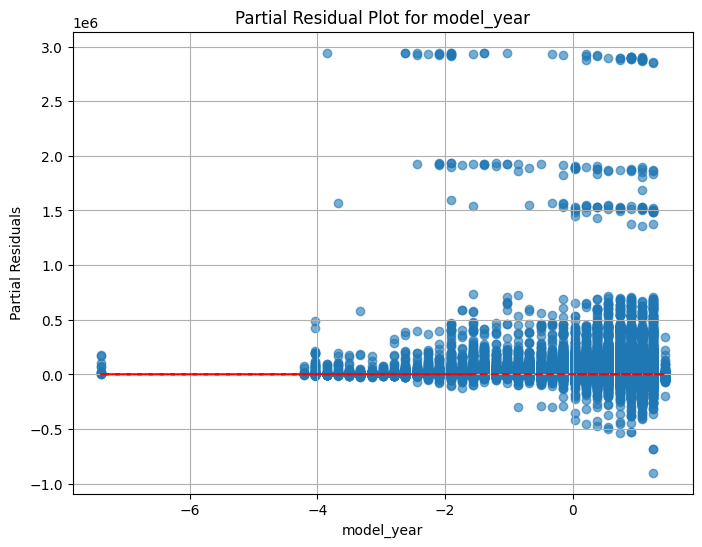

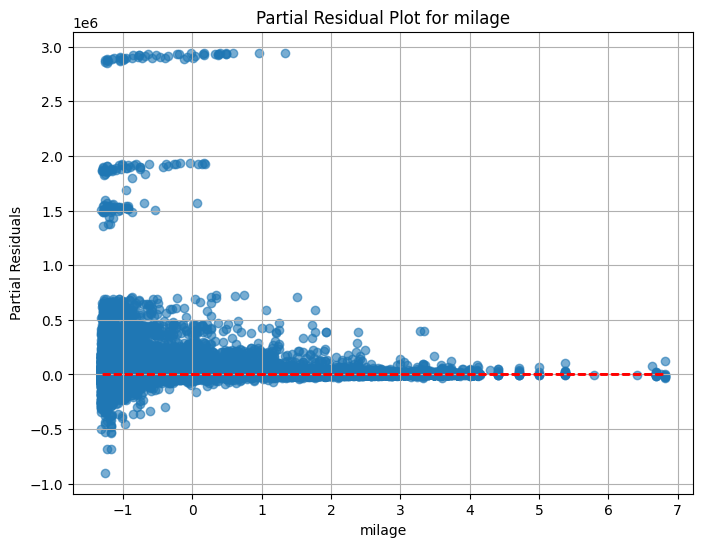

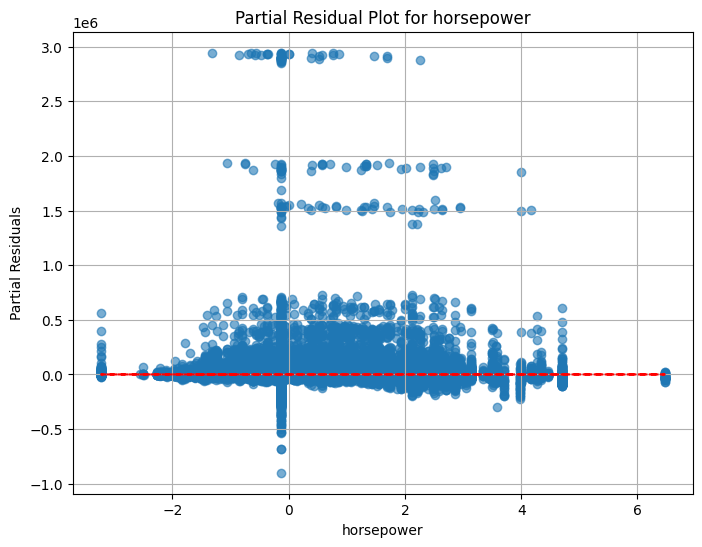

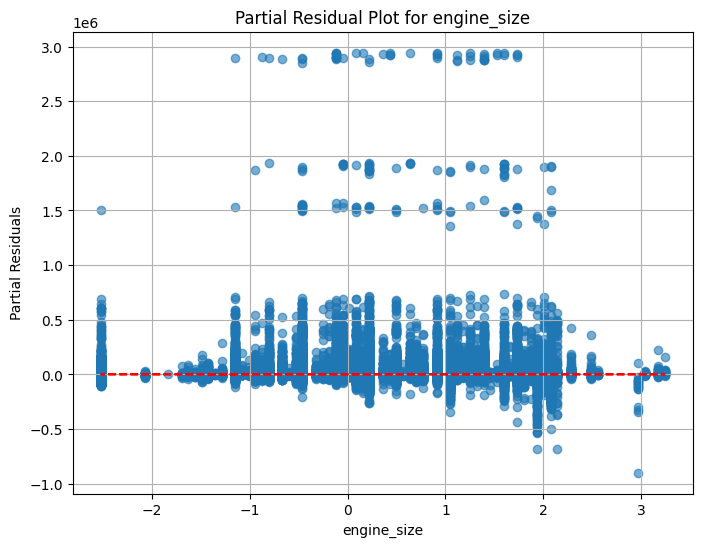

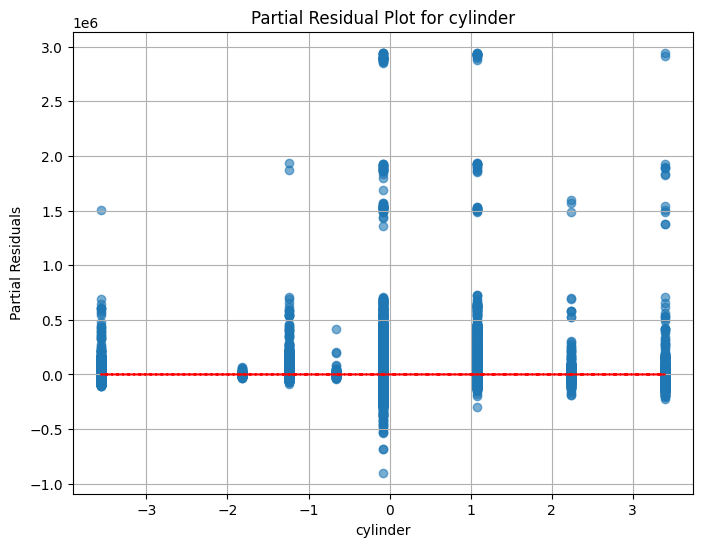

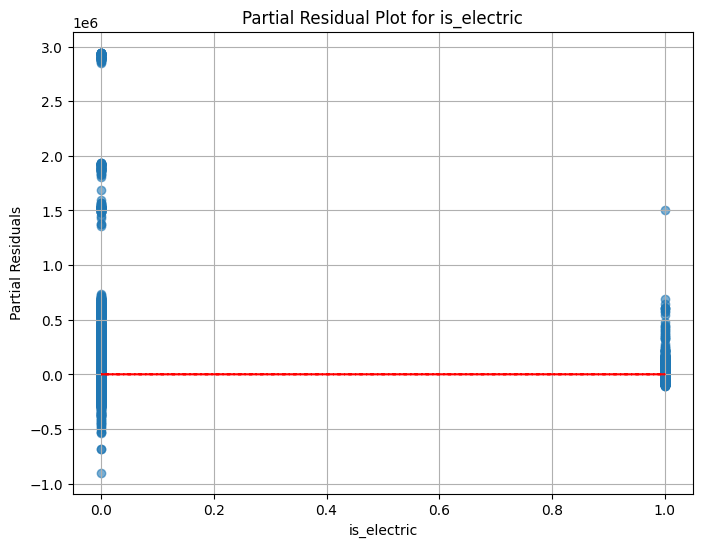

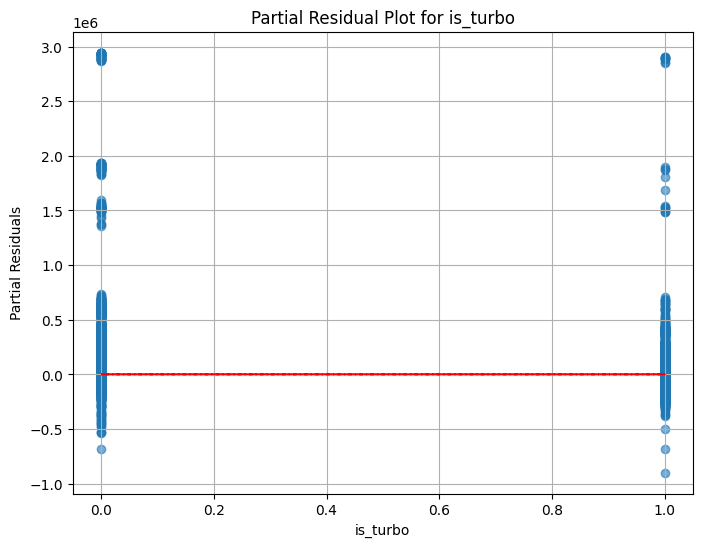

In [ ]:
residual = y_train - y_pred_wls

# 2. Iterasi untuk setiap fitur dan plot residual parsial
for feature in X_train_poly[num_cols]:
    # Hitung residual parsial
    partial_residual = residual + (coefficients[feature] * X_train_poly[feature])

    plt.figure(figsize=(8, 6))

    # Plot titik data
    plt.scatter(X_train_poly[feature], partial_residual, alpha=0.6)

    # Tambahkan garis regresi (garis lurus)
    # Sumbu Y = (beta * X) + residual
    # Y = (beta * X) + (y - y_pred)
    # Jika modelnya benar, titik-titik harus tersebar di sekitar garis ini
    plt.plot(X_train_poly[feature], coefficients[feature] * X_train_poly[feature], color='red', linestyle='--')

    plt.title(f'Partial Residual Plot for {feature}')
    plt.xlabel(feature)
    plt.ylabel('Partial Residuals')

    plt.grid(True)
    plt.show()

### Mixed-Effect Model

In [ ]:
def OHencoder2_fit(X):
  cat_cols = ['fuel_type','transmission','ext_col','int_col','accident', 'clean_title','fuel_system']
  ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore',).set_output(transform="pandas")
  ohe.fit(X[cat_cols])
  return ohe

def encoder2_transform(X, encoder):
  cat_cols = ['fuel_type','transmission','ext_col','int_col','accident', 'clean_title','fuel_system']
  encoded = encoder.transform(X[cat_cols])
  df_encoded = pd.concat([X.drop(columns=cat_cols), encoded], axis=1)
  return df_encoded

In [ ]:
ohe_2 = OHencoder2_fit(X_train_scaled)
df_encoded_2 = encoder2_transform(X_train_scaled, ohe_2)

In [ ]:
# Gabungkan X_train_poly + y_log
df_me = pd.concat([df_encoded_2, y_log], axis=1)
# Replace spasi, -, / menjadi underscore
df_me.columns = [c.replace(" ", "_").replace("-", "_").replace("/", "_") for c in df_me.columns]
df_me.drop('model', axis = 1,inplace = True)

In [ ]:
df_me

,brand,model_year,milage,horsepower,engine_size,cylinder,is_electric,is_turbo,fuel_type_Diesel,fuel_type_E85_Flex_Fuel,...,fuel_system_HP_Electric_Motor_Hydrogen_Fuel,fuel_system_L_Electric_Motor_Electric_Fuel_System,fuel_system_L_Rotary_engine_Gasoline_Fuel,fuel_system_Unknown,fuel_system_V_GDI_DOHC_Flexible_Fuel,fuel_system_V_GDI_DOHC_Turbo_Flexible_Fuel,fuel_system_V_MPFI_DOHC_Flexible_Fuel,fuel_system_V_MPFI_OHV_Flexible_Fuel,fuel_system_V_MPFI_SOHC_Flexible_Fuel,price
id,,,,,,,,,,,,,,,,,,,,,
0,MINI,-1.559808,2.957842,-1.592944,-1.422728,-1.241171,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.342840
1,Lincoln,-2.443052,1.557184,-0.832373,0.154695,1.078088,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.516993
2,Chevrolet,-2.443052,1.426276,-0.185887,1.114866,1.078088,0,0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,9.539644
3,Genesis,0.206679,-0.927854,0.764827,0.909115,1.078088,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.714418
4,Mercedes-Benz,0.913274,-1.171076,-1.250687,-1.148393,-1.241171,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.487608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188528,Cadillac,0.206679,-0.335461,0.764827,1.732119,1.078088,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.221941
188529,Mercedes-Benz,0.383328,-0.745116,0.432077,-0.462557,-0.081541,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.308953
188530,Mercedes-Benz,0.913274,-1.045328,1.230677,0.223279,1.078088,0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.372513


In [ ]:
import statsmodels.formula.api as smf

In [ ]:
predictors = [f"{c}" for c in df_me.columns if c not in ["price", "brand", "id"]]
formula = "price ~ " + " + ".join(predictors)
model = smf.mixedlm(formula, df_me, groups=df_me["brand"]).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/base/m

In [ ]:
y_pred = np.exp(model.predict(df_me))

In [ ]:
print("RMSE: ", np.sqrt(mean_squared_error(y_train, y_pred)))

RMSE:  74982.81850889424


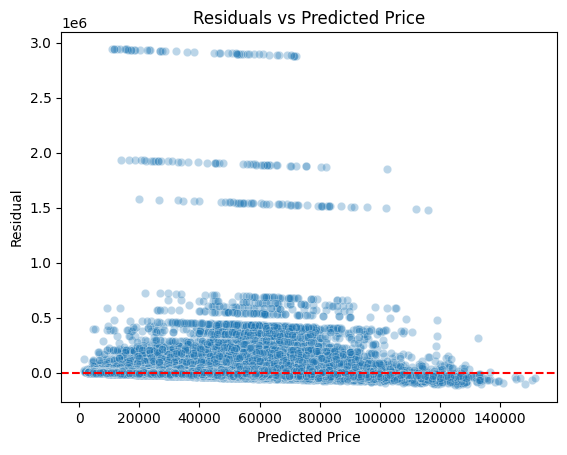

In [ ]:
residual_plot(y_train, y_pred)

In [ ]:
df_me['residual'] = y_train - y_pred
df_outliers = df_me[df_me['residual'].abs() > 1000000].index
df_outliers

Index([   220,   1880,   2964,   4164,   8789,  10173,  13838,  14693,  15101,
        16034,
       ...
       176936, 178025, 180945, 181021, 183006, 183262, 183468, 185197, 186234,
       188194],
      dtype='int64', name='id', length=148)

#### Residual analysis

In [ ]:
def residual_plot(y_train, y_pred):
  residuals = y_train - y_pred
  df_resid = pd.DataFrame({
    "y_true": y_train,
    "y_pred": y_pred,
    "residuals": residuals,
    "brand": X_train["brand"].values})
  sns.scatterplot(x="y_pred", y="residuals", data=df_resid, alpha=0.3)
  plt.axhline(0, color="red", linestyle="--")
  plt.xlabel("Predicted Price")
  plt.ylabel("Residual")
  plt.title(f"Residuals vs Predicted Price")
  plt.show()

- Perhatikan bahwa terdapat tren menurun semakin besar nilai predicted pricenya.
- Perlu dilakukan analisis lebih lanjut mengenai data point yang memiiliki nilai residual di sekitar 2.0, 1.5, dan 3.0.

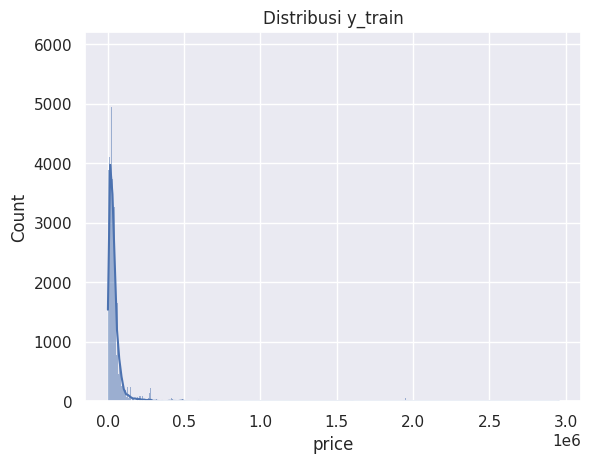

In [ ]:
sns.histplot(y_train, kde=True)
plt.title("Distribusi y_train")
plt.show()

In [ ]:
lux_car = X_train.loc[y_train[y_train> 500_000].index]
lux_car

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
id,,,,,,,,,,,
220,Ford,F-150 XLT,2021,26315,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,Agate Black Metallic,Black,None reported,Yes
1204,BMW,M550 i xDrive,2018,12500,Gasoline,456.0HP 4.4L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes
1880,Chrysler,300C Base,2003,55900,Gasoline,340.0HP 5.7L 8 Cylinder Engine Gasoline Fuel,5-Speed A/T,Beige,Beige,None reported,Yes
2366,Porsche,911 Carrera S,2020,1750,Gasoline,443.0HP 3.0L Flat 6 Cylinder Engine Gasoline Fuel,8-Speed A/T,Gray,Black,None reported,Yes
2964,Porsche,911 R,2023,714,Gasoline,4.0L H6 24V GDI DOHC,6-Speed Manual,White,Gray,None reported,Yes
...,...,...,...,...,...,...,...,...,...,...,...
185530,Porsche,911 Carrera 4S,2023,9000,Gasoline,379.0HP 3.0L Flat 6 Cylinder Engine Gasoline Fuel,7-Speed A/T,White,Black,None reported,Yes
186234,Land,Rover Range Rover Sport HSE,2017,2437,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,A/T,Black,Black,None reported,Yes
186598,Ford,Mustang Mach-E Premium,2023,8755,NaN,346.0HP Electric Motor Electric Fuel System,1-Speed A/T,White,Black,None reported,Yes


In [ ]:
lux_car['model'].value_counts()

,count
model,
911 GT3,10
Ghost Base,7
M4 Base,7
911 Turbo Cabriolet,7
1500 Laramie,6
...,...
Rover LR4 Lux,1
Rover Range Rover Sport Supercharged HSE,1
Mustang Mach-E Premium,1


In [ ]:
model_ctn = X_train['model'].value_counts()
model_ctn[model_ctn>1]

,count
model,
F-150 XLT,2945
M3 Base,2229
Camaro 2SS,1709
M4 Base,1622
Mustang GT Premium,1526
...,...
X5 xDrive 35i Sport Activity,2
V60 T6 R-Design Platinum,2
X3 xDrive35i,2


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

X_const = add_constant(X_train_clean)

# Hitung VIF per variabel
vif = pd.DataFrame()
vif["Variable"] = X_const.columns
vif["VIF"] = [variance_inflation_factor(X_const.values, i)
              for i in range(X_const.shape[1])]

print(vif)

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1782: RuntimeWarning: divide by zero encountered in scalar divide
  return 1 - self.ssr/self.centered_tss
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


                                       Variable       VIF
0                                         const  0.000000
1                                    model_year  2.629721
2                                        milage  2.182775
3                                    horsepower  3.827537
4                                   engine_size  6.111593
..                                          ...       ...
110        fuel_system_V GDI DOHC Flexible Fuel       inf
111  fuel_system_V GDI DOHC Turbo Flexible Fuel       inf
112       fuel_system_V MPFI DOHC Flexible Fuel       inf
113        fuel_system_V MPFI OHV Flexible Fuel       inf
114       fuel_system_V MPFI SOHC Flexible Fuel       inf

[115 rows x 2 columns]


In [ ]:
print("Range:", (y_train.min(), y_train.max()))

Range: (2000, 2954083)


In [ ]:
def plot_residuals_vs_features(df, y_true, y_pred, num_cols):
    df['residual'] = y_true - y_pred
    df['is_outlier'] = df.index.isin(df_outliers)
    for col in num_cols:
        sns.scatterplot(
            data=df,
            x=col,
            y='residual',
            hue='is_outlier',
            palette={True: 'red', False: 'blue'},
            s=100,
            alpha=0.7
        )
        plt.axhline(0, color='black', linestyle="--")
        plt.xlabel(col)
        plt.ylabel("Residual")
        plt.title(f"Residuals vs {col}")
        plt.show()

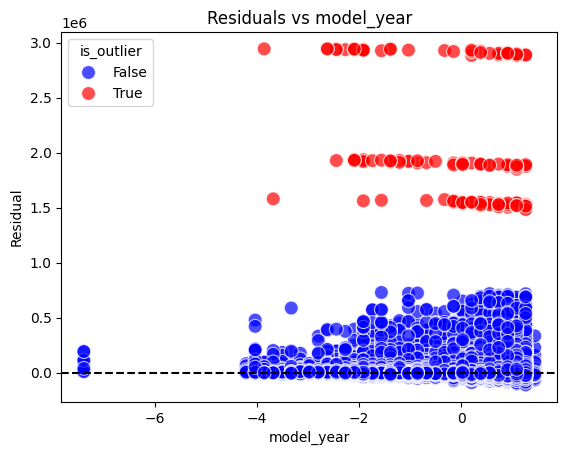

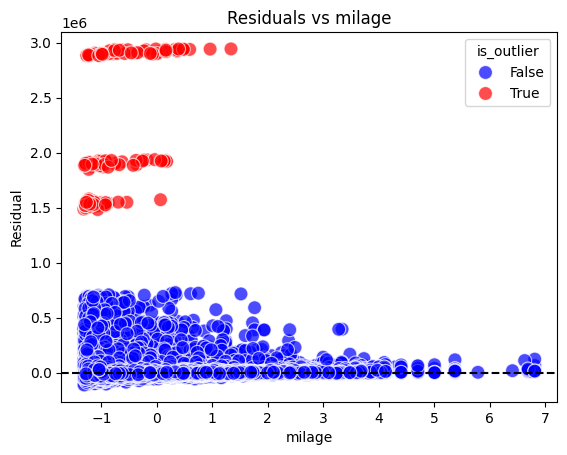

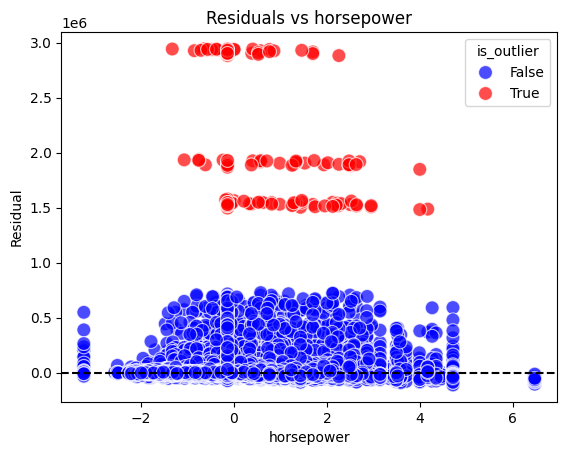

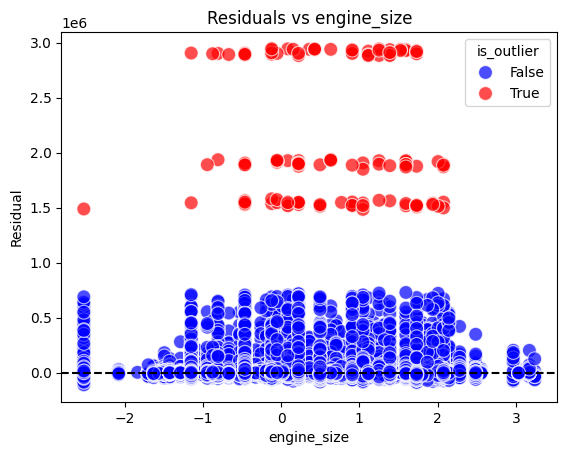

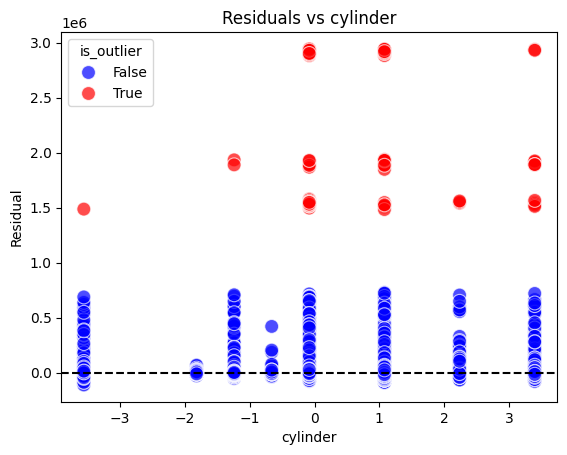

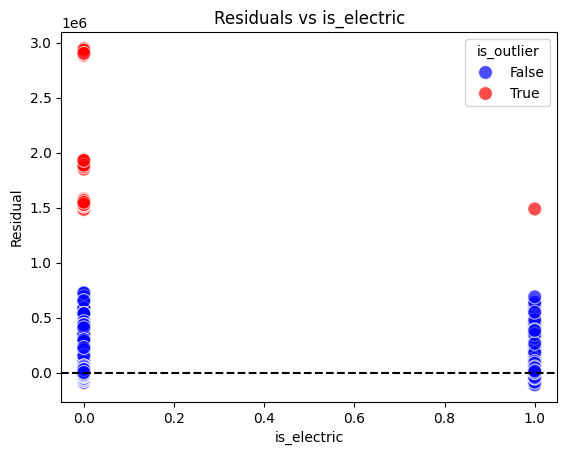

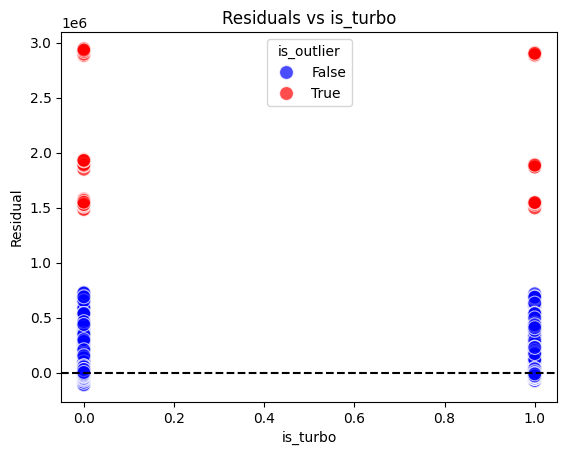

In [ ]:
plot_residuals_vs_features(X_train_clean, y_train, y_pred, num_cols)

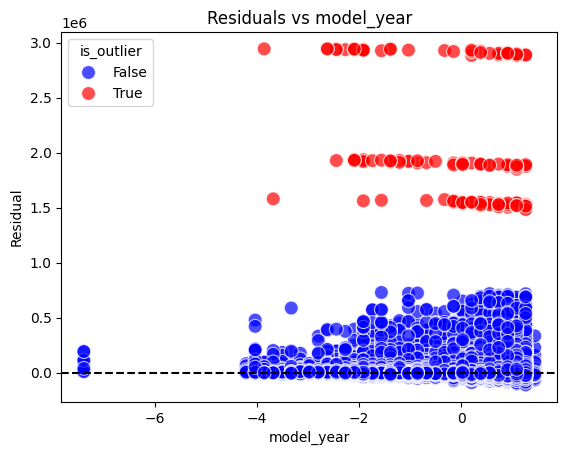

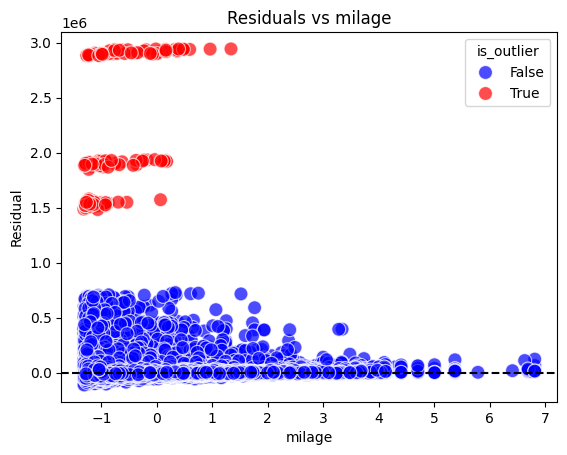

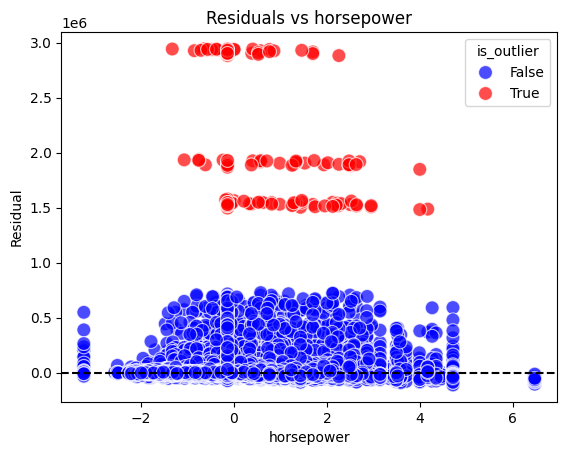

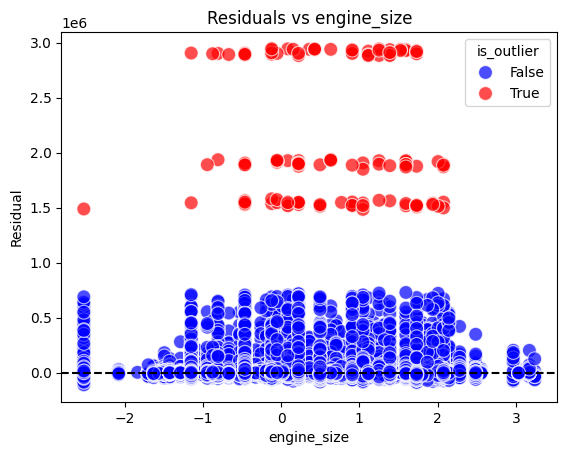

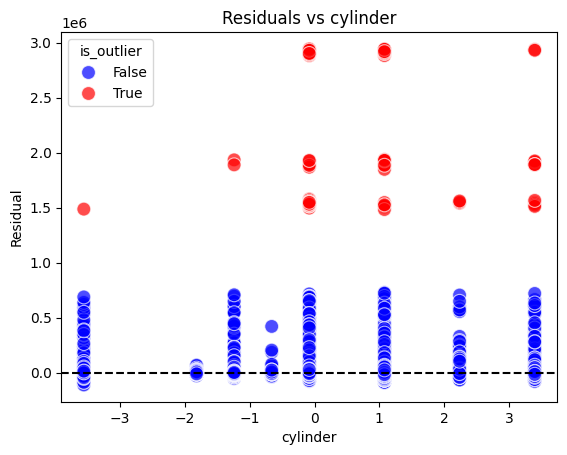

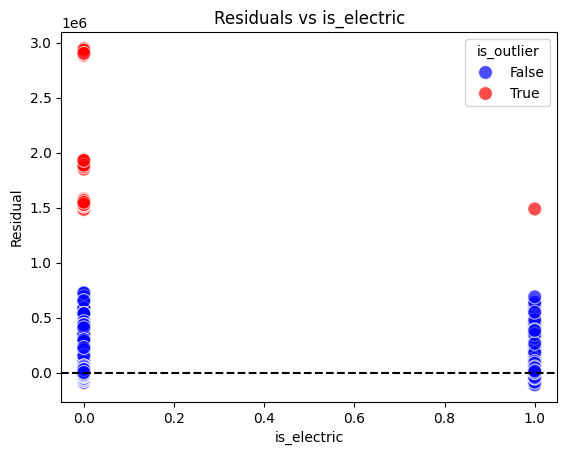

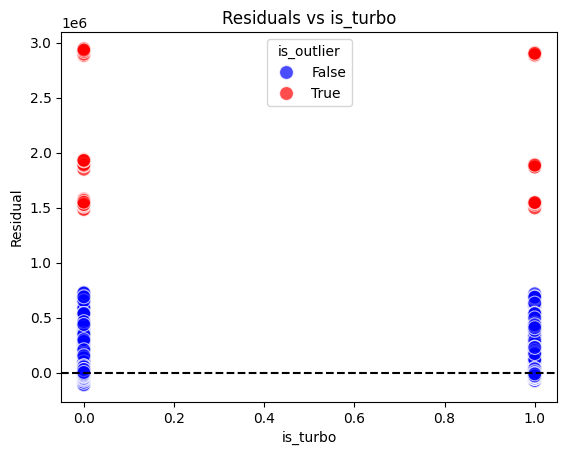

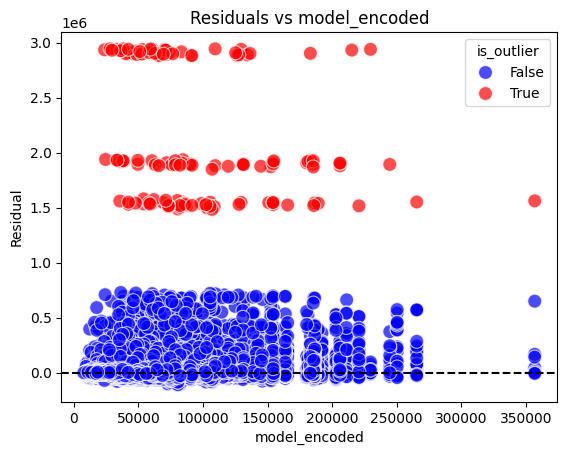

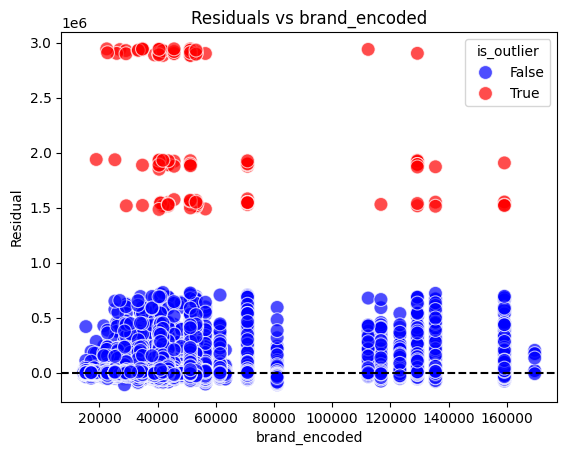

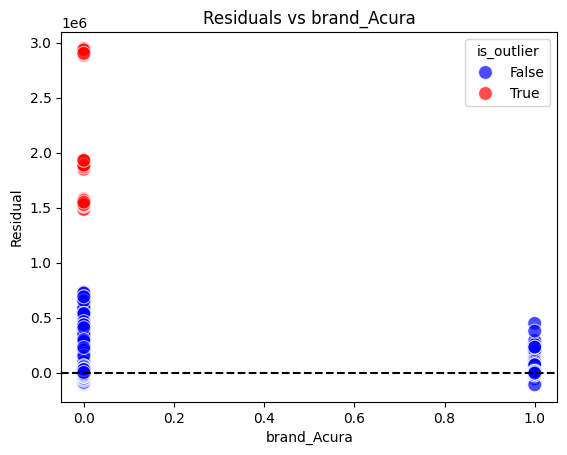

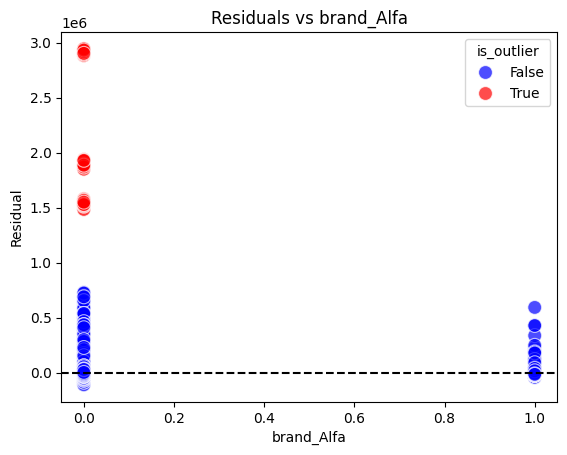

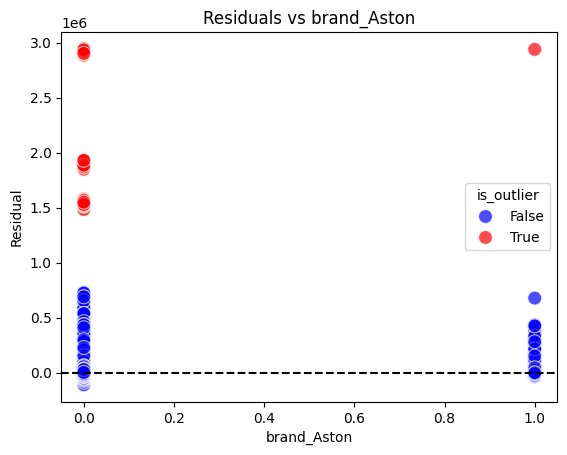

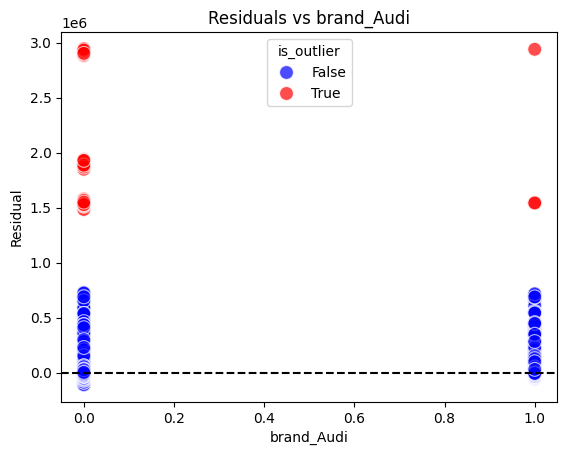

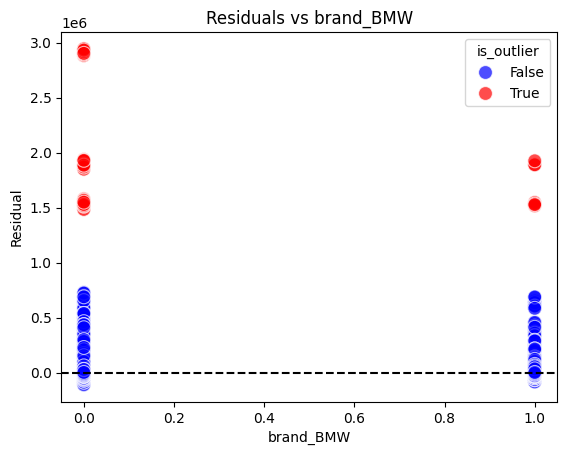

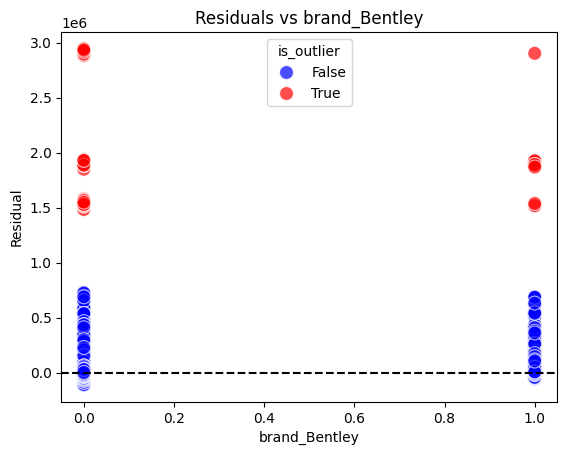

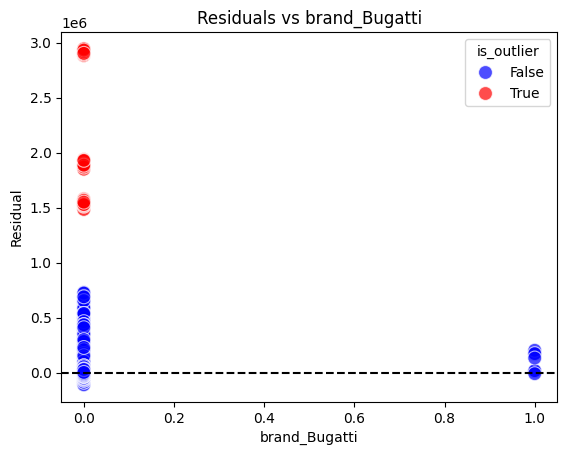

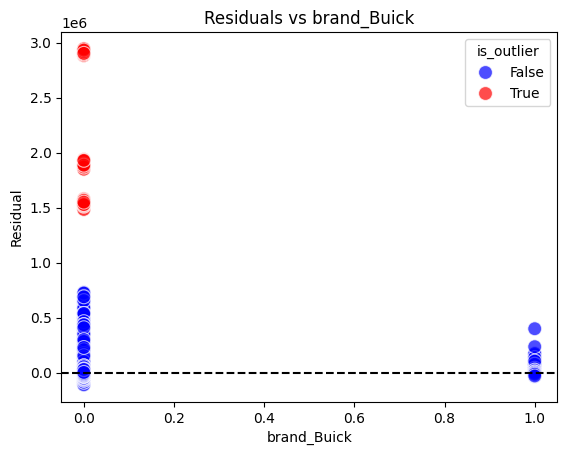

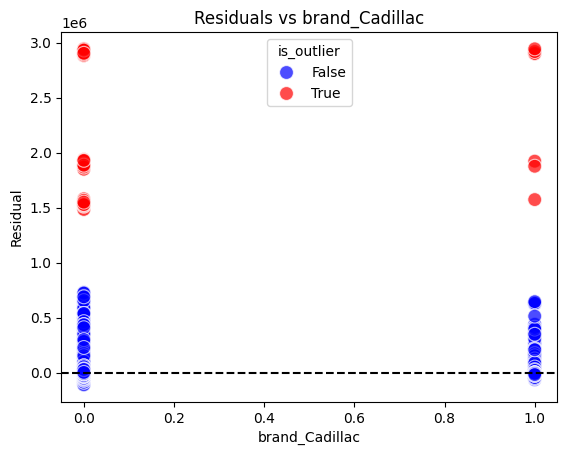

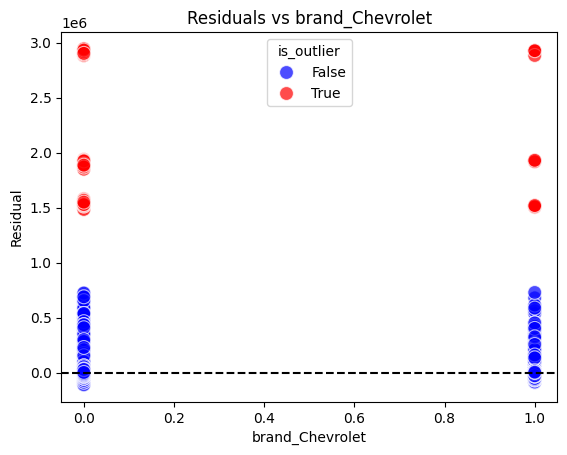

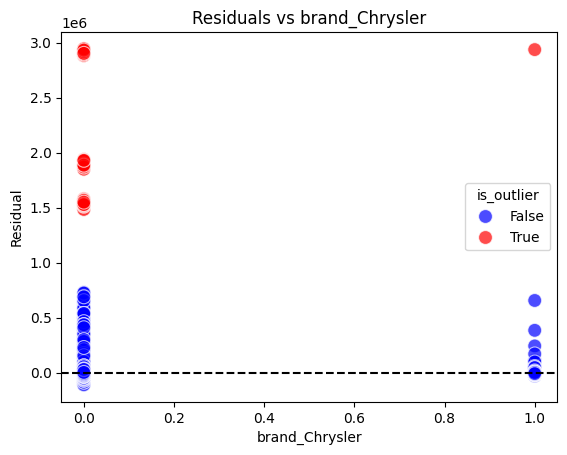

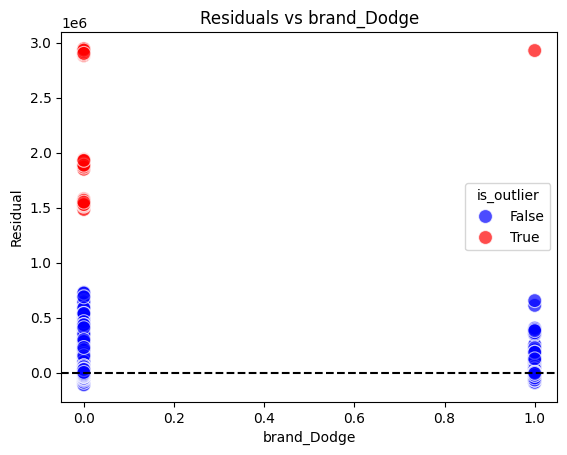

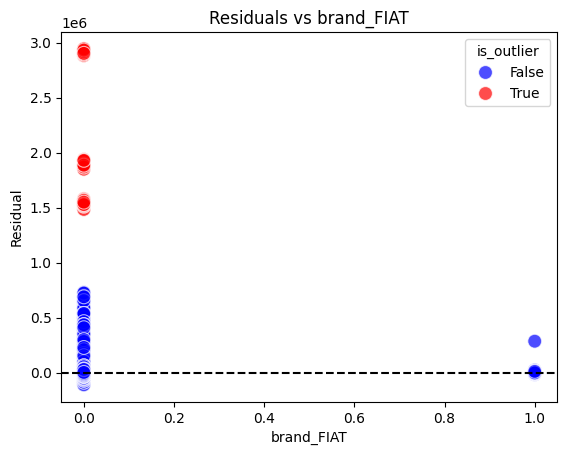

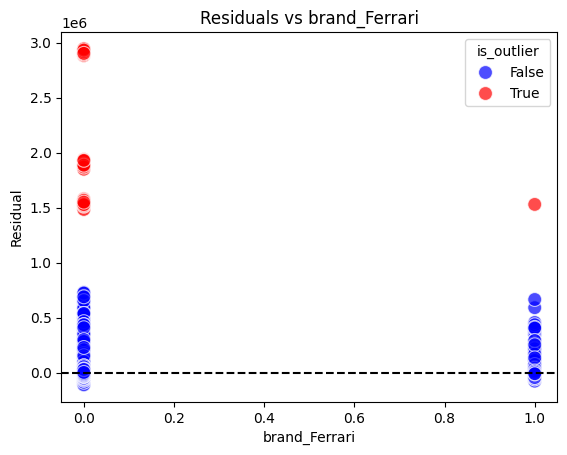

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


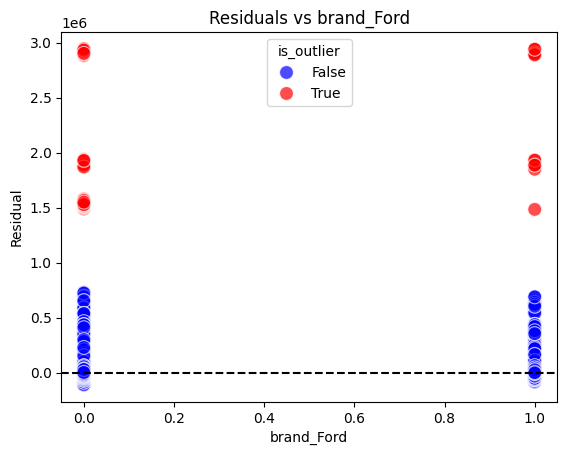

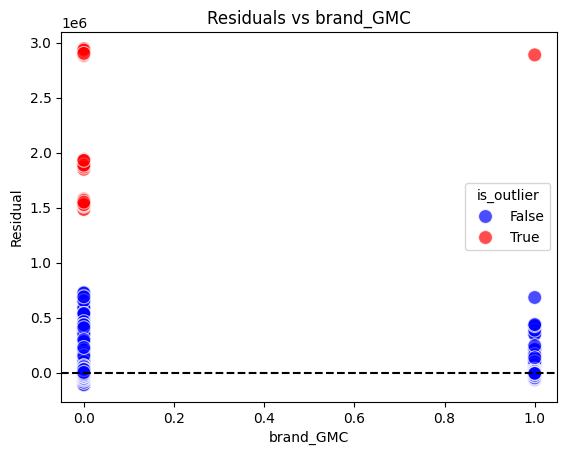

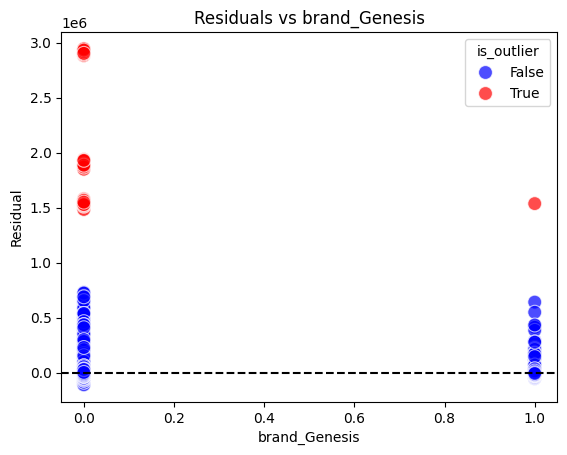

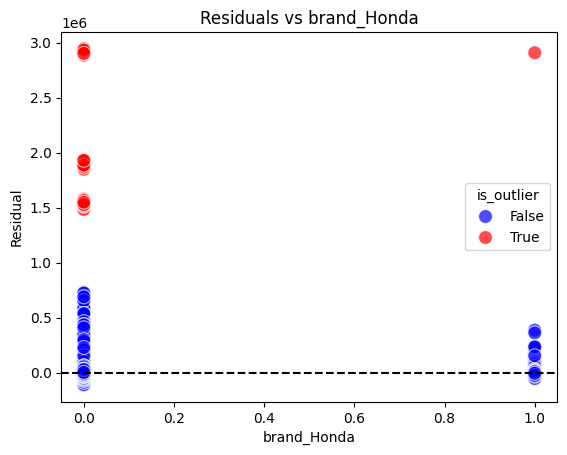

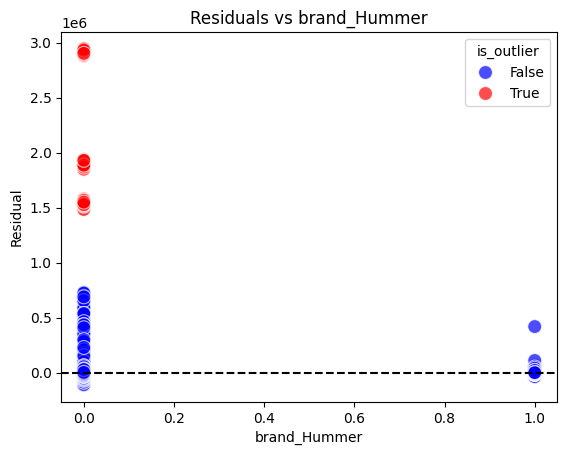

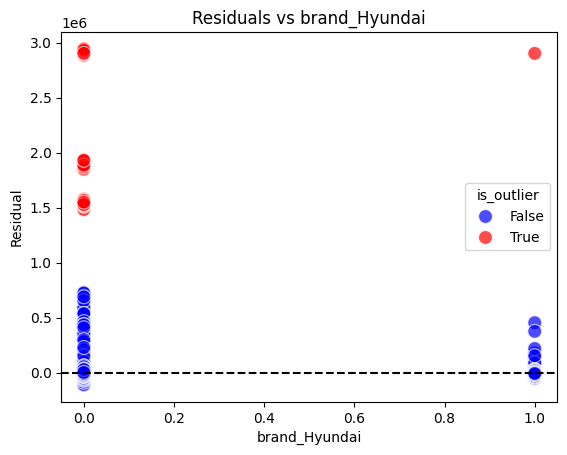

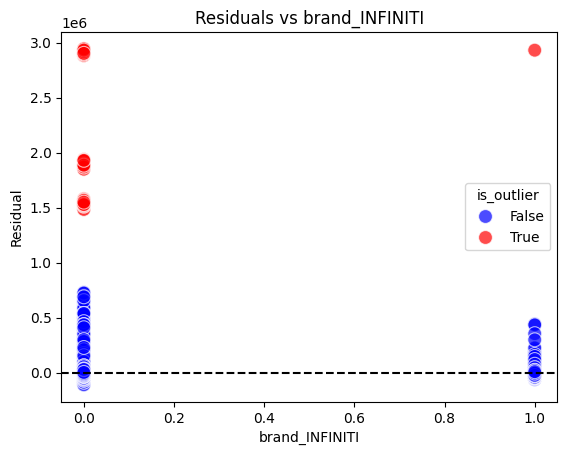

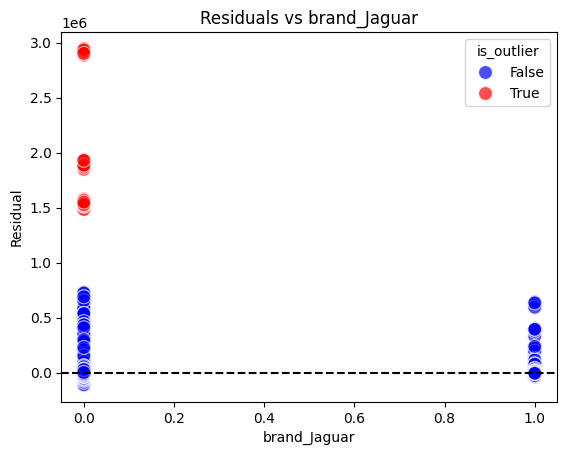

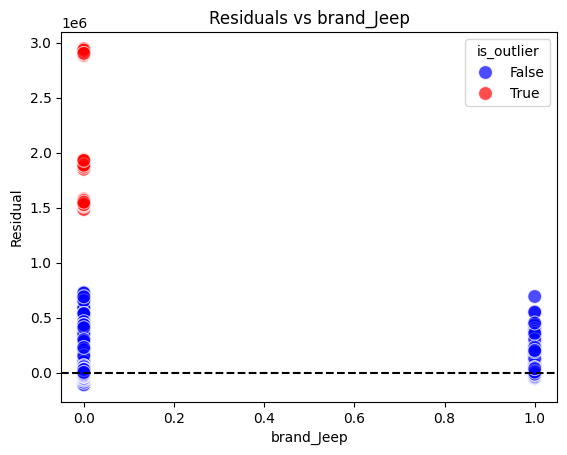

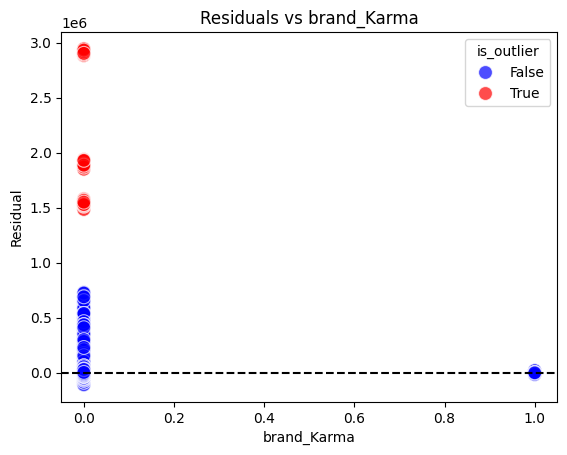

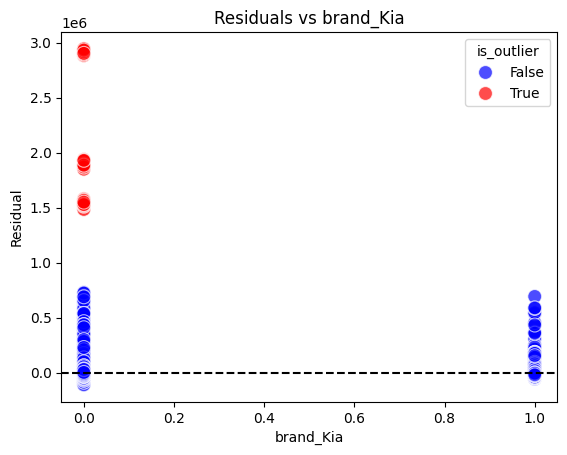

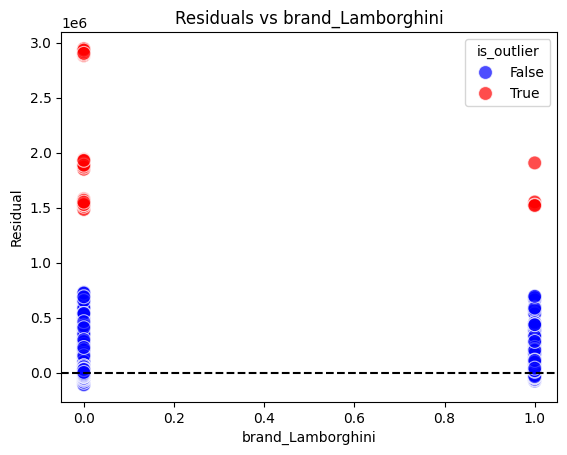

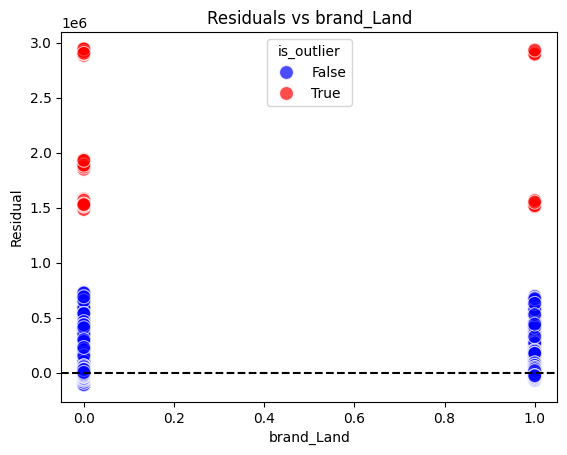

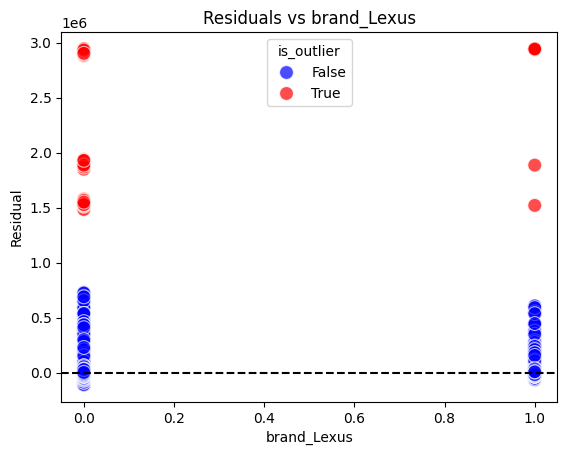

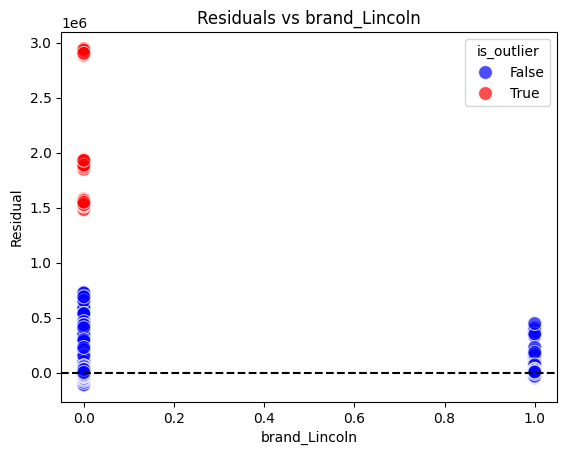

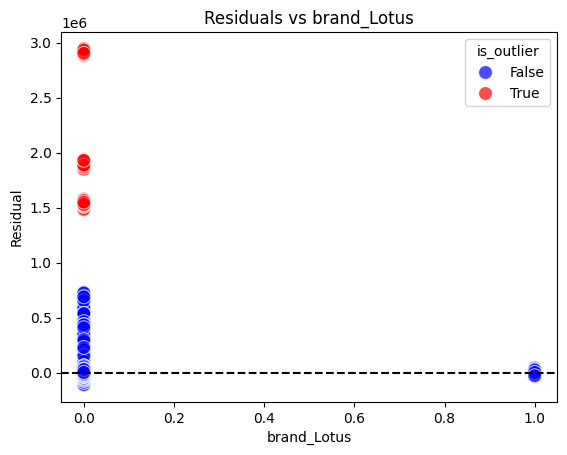

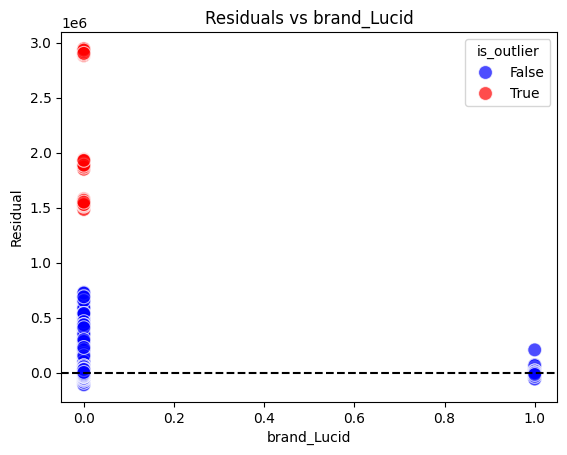

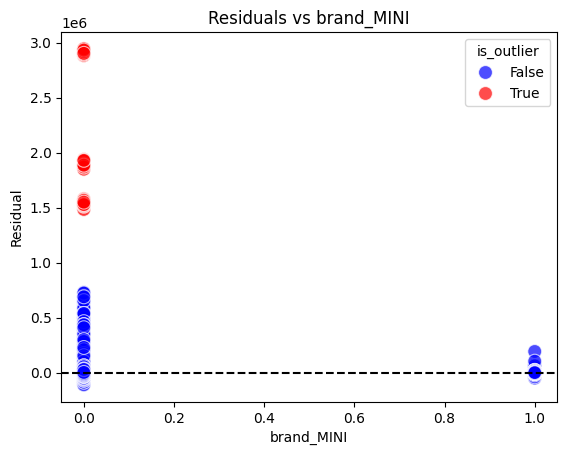

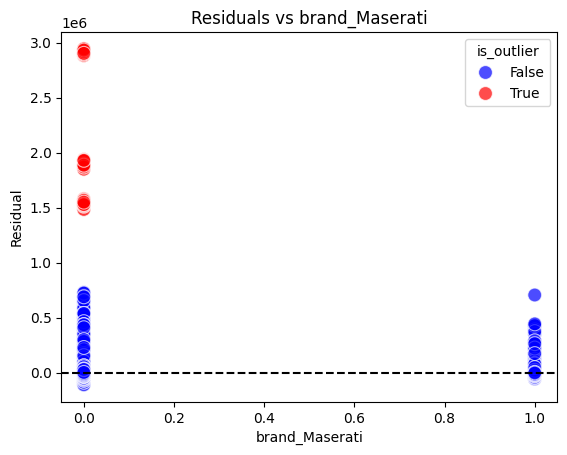

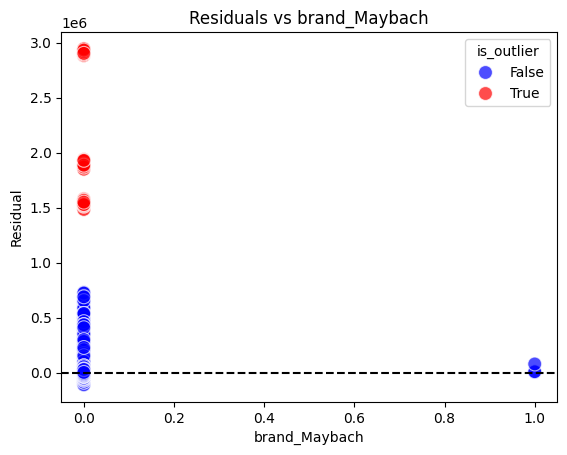

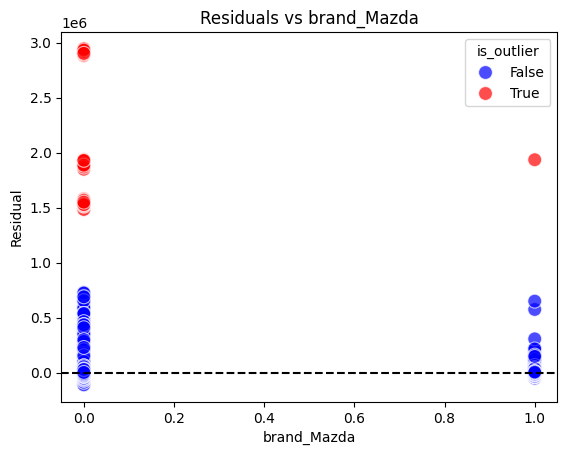

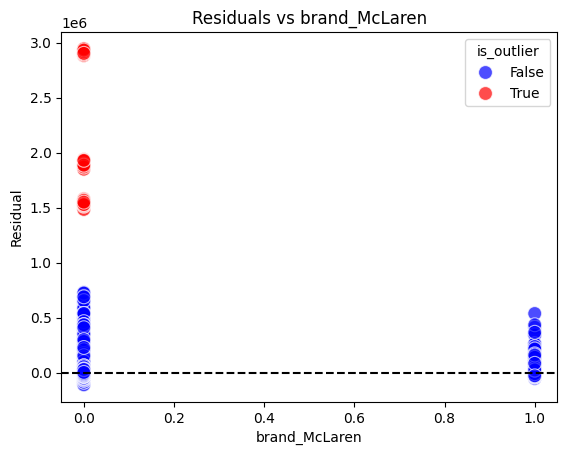

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


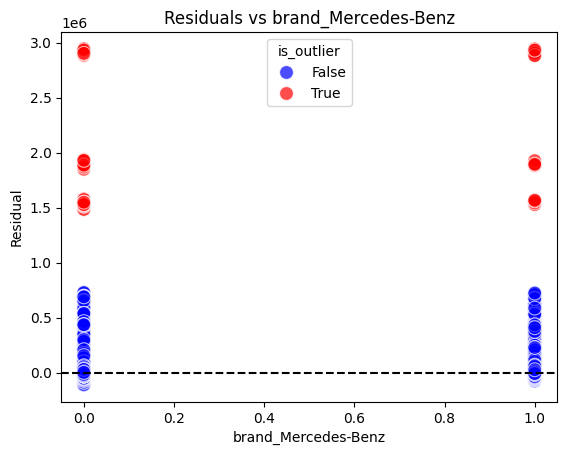

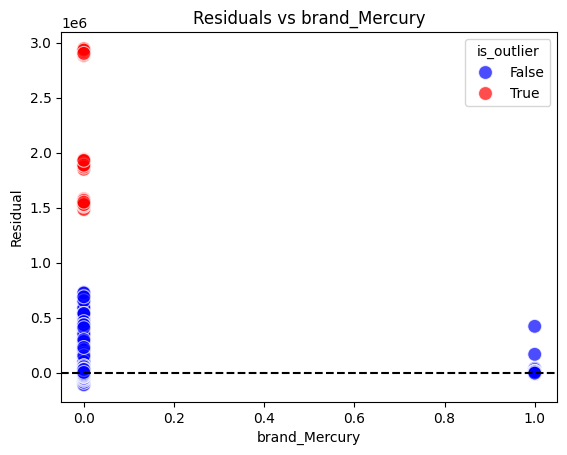

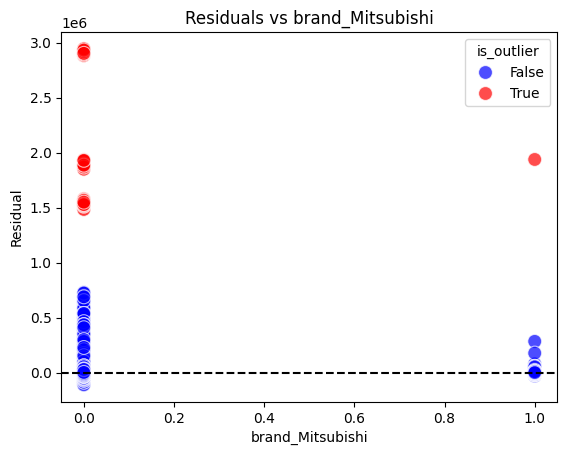

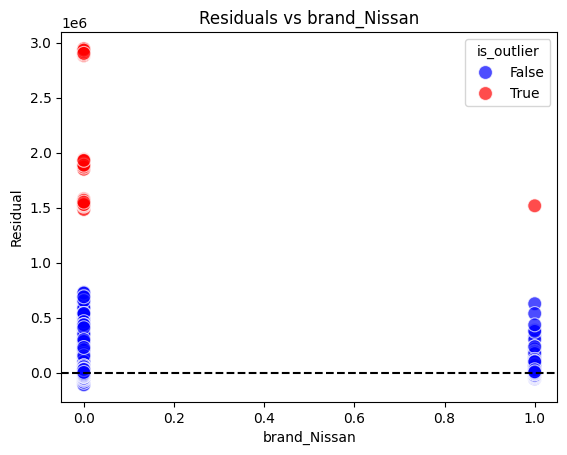

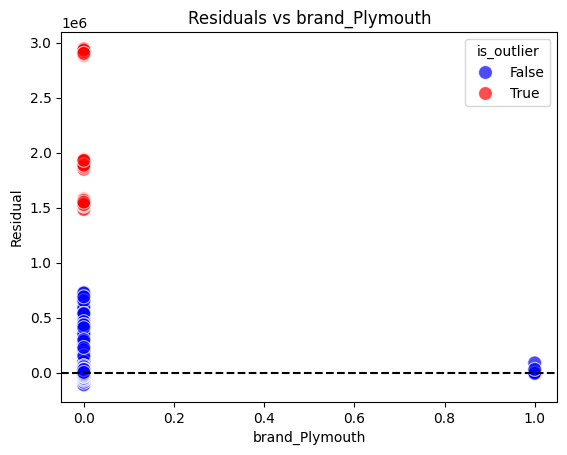

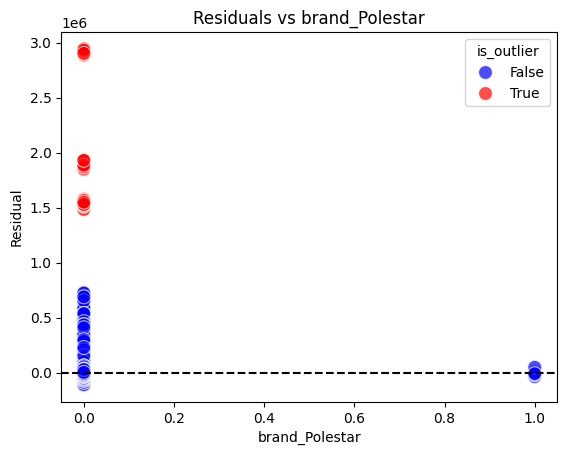

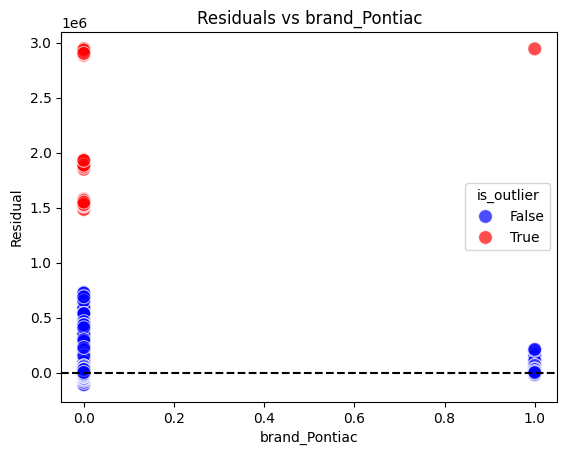

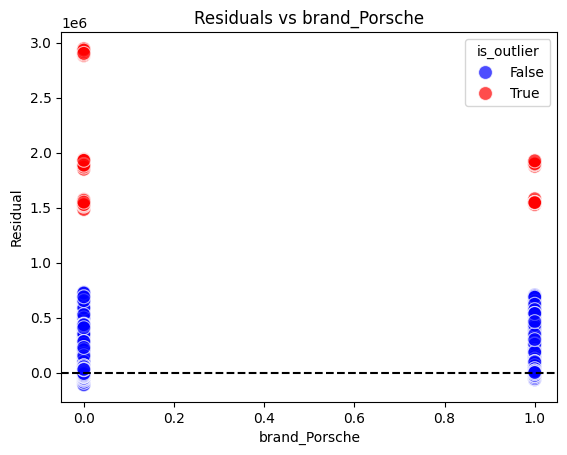

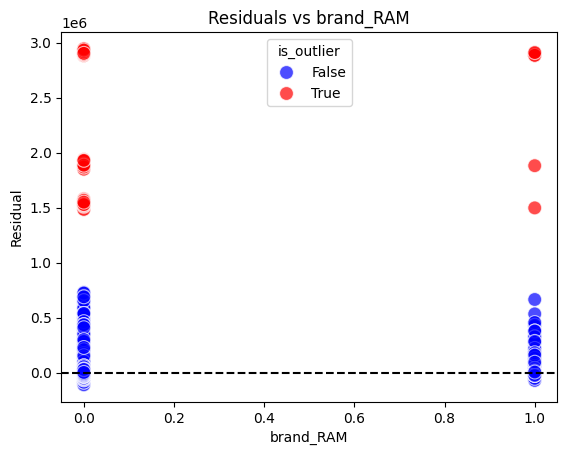

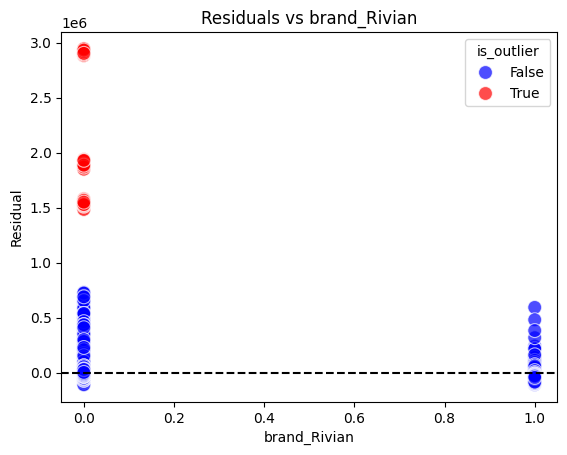

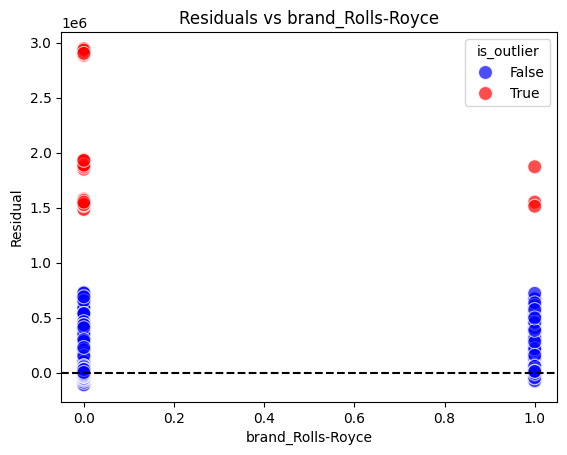

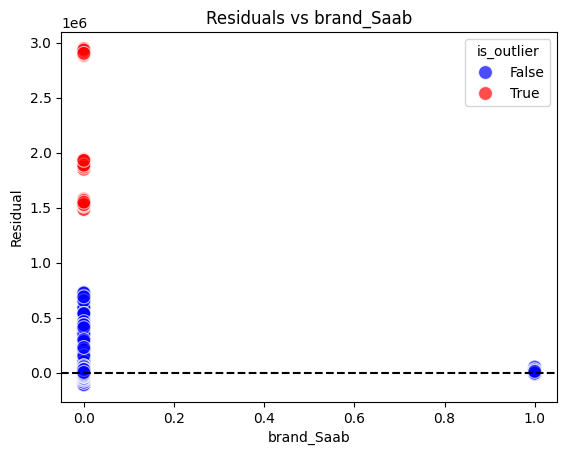

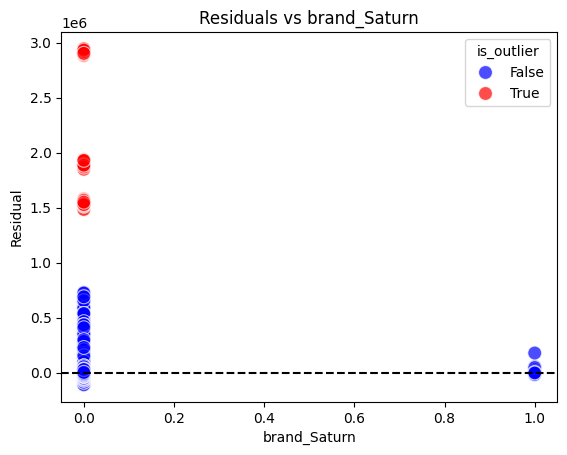

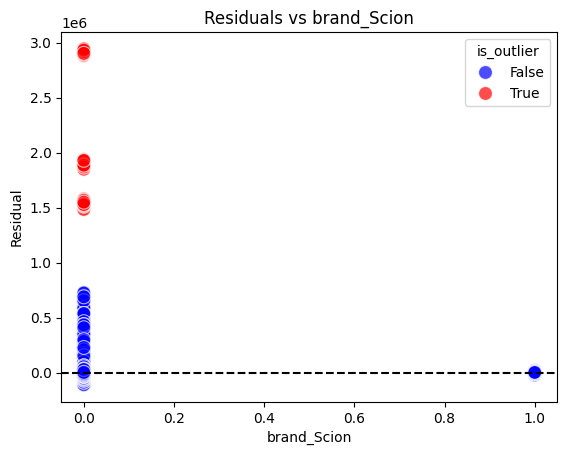

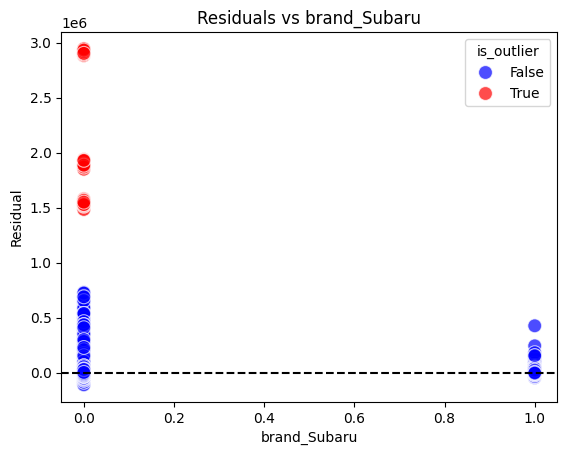

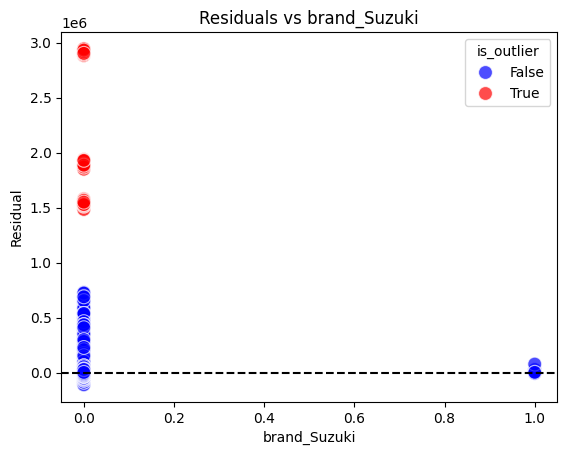

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


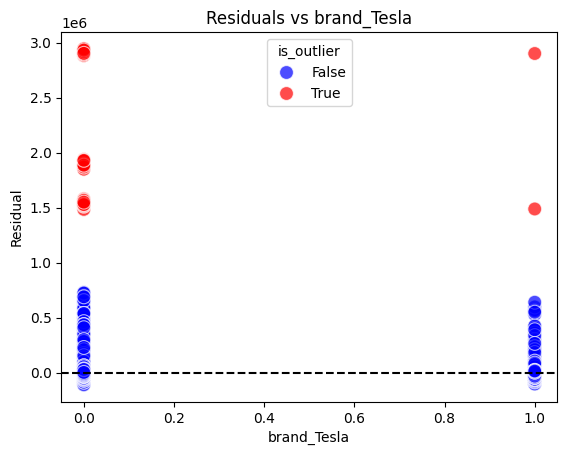

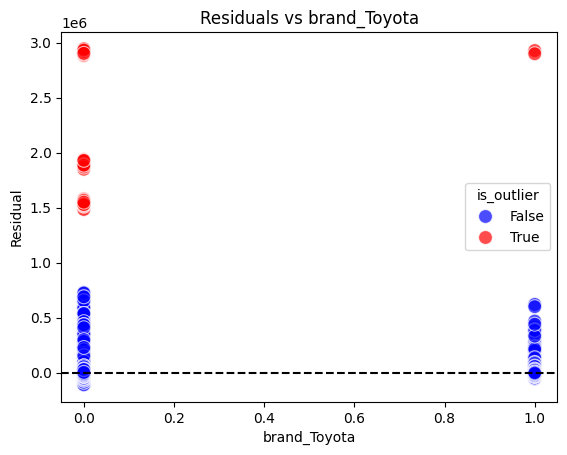

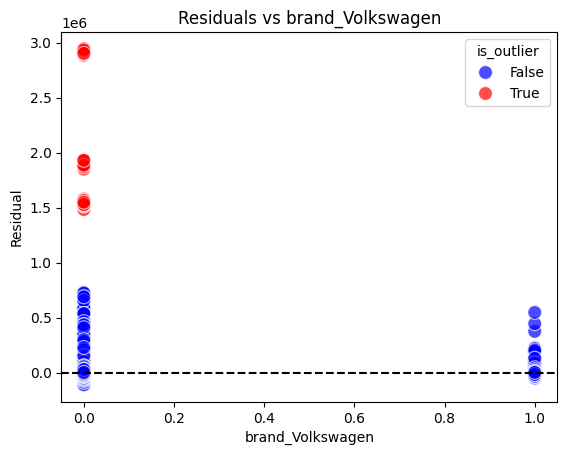

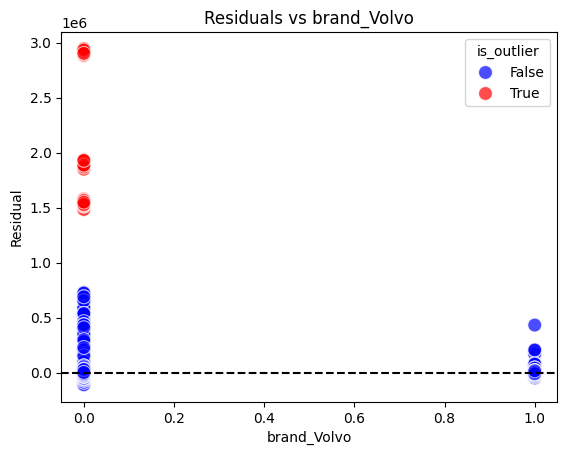

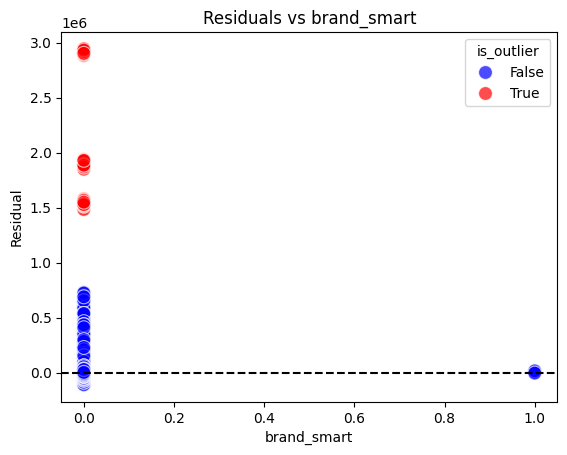

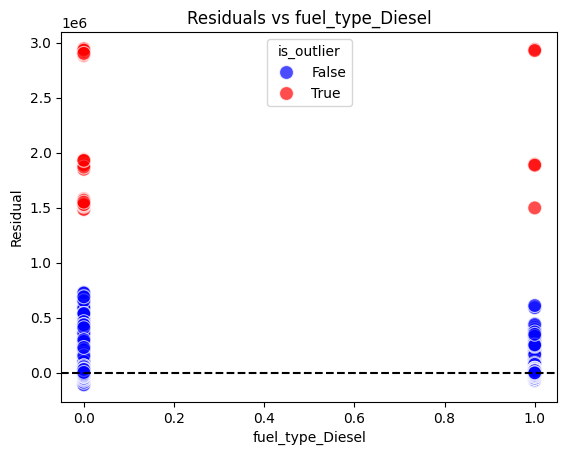

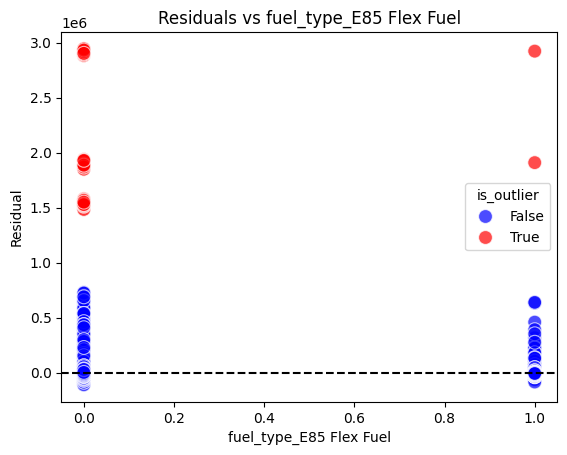

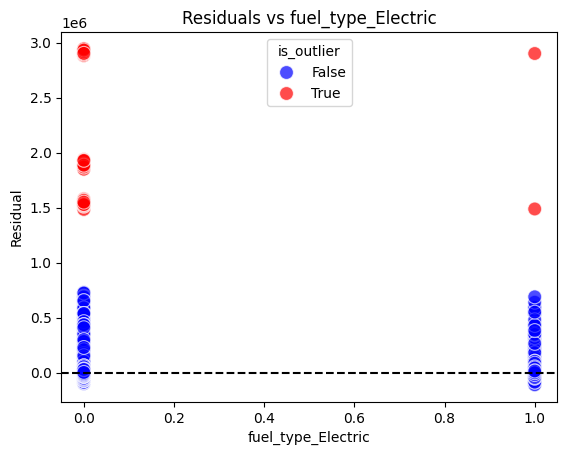

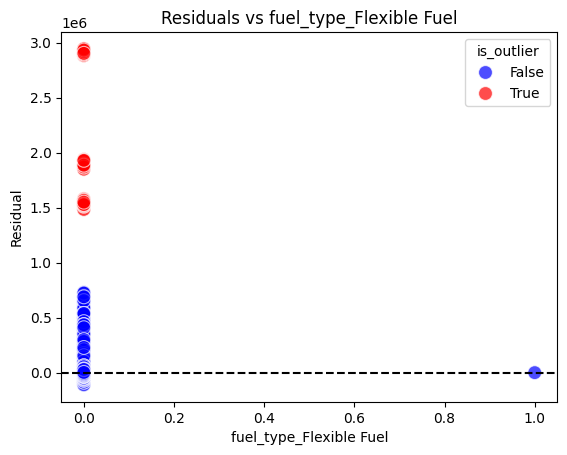

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


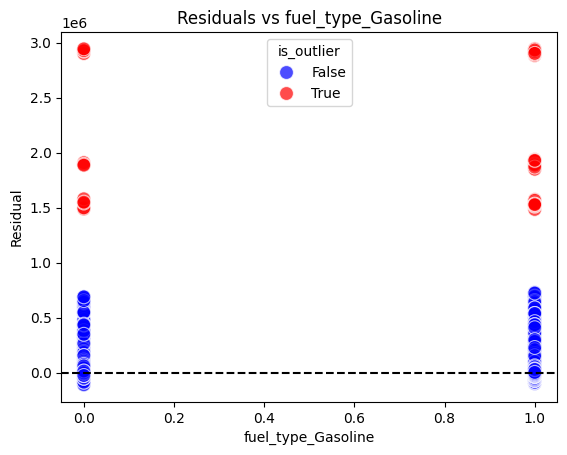

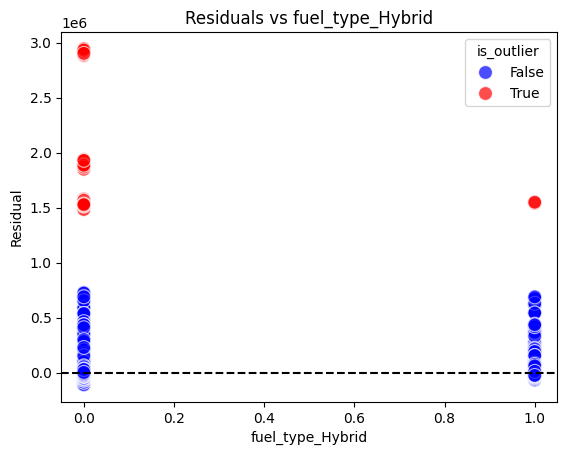

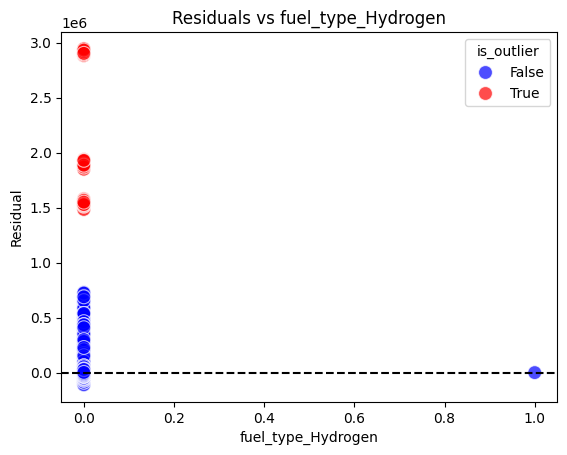

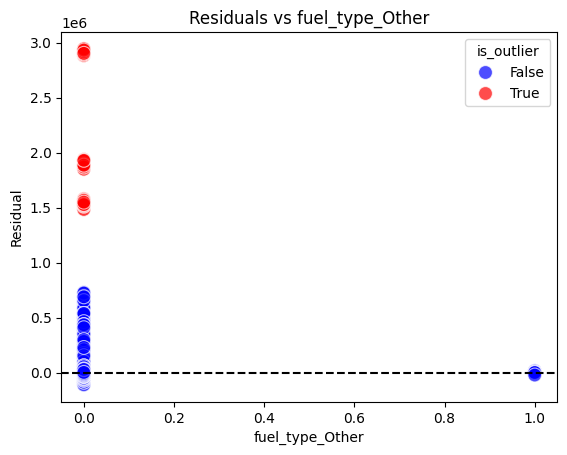

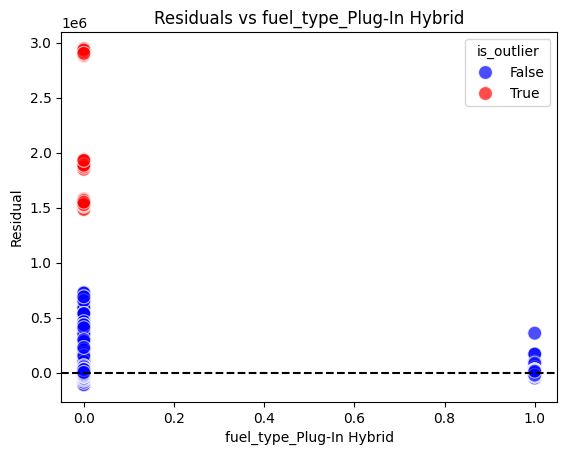

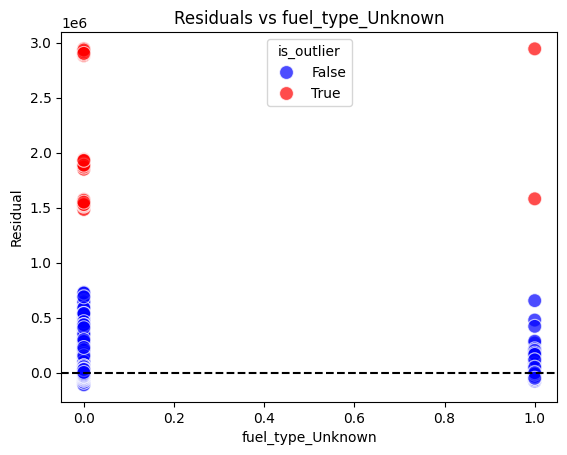

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


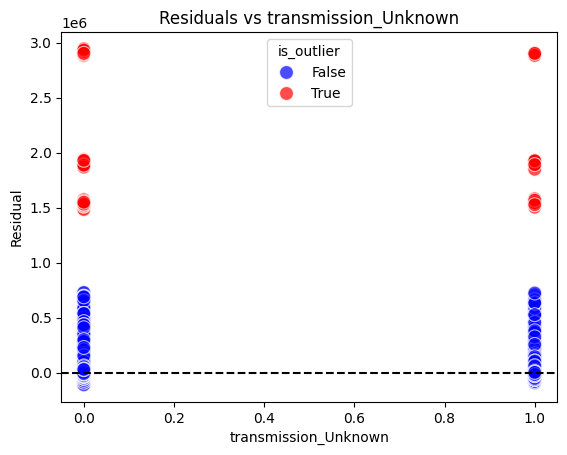

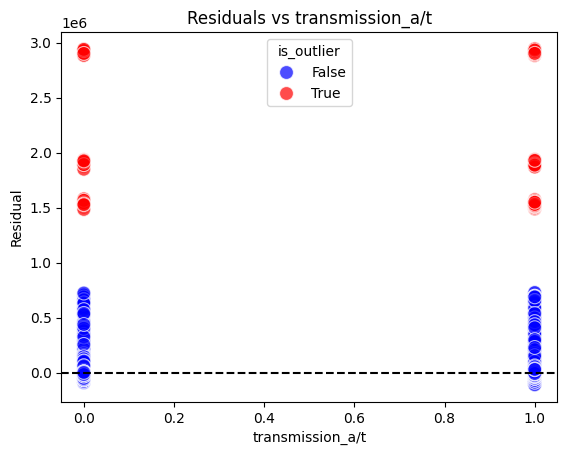

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


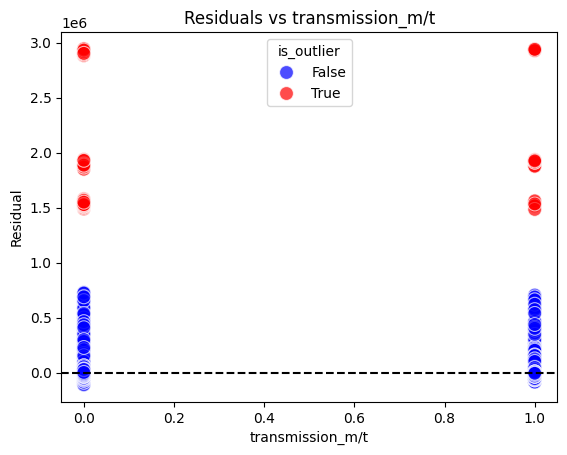

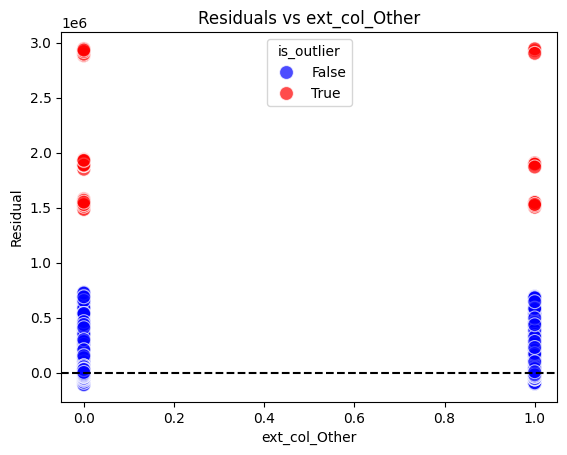

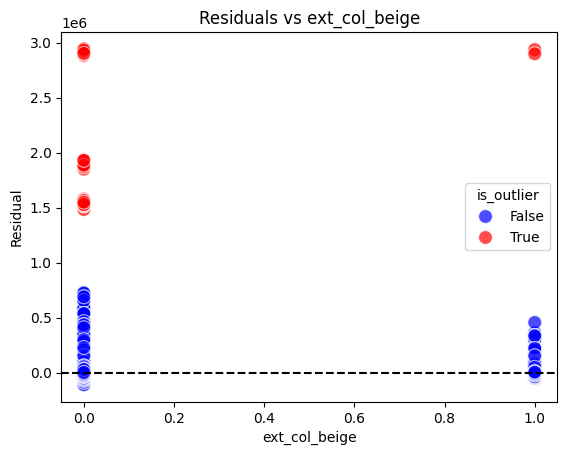

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


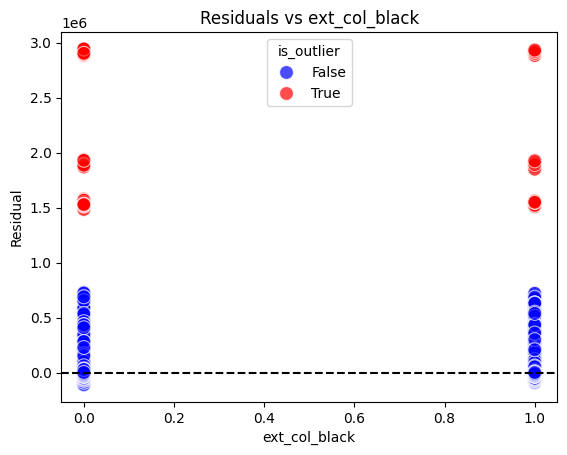

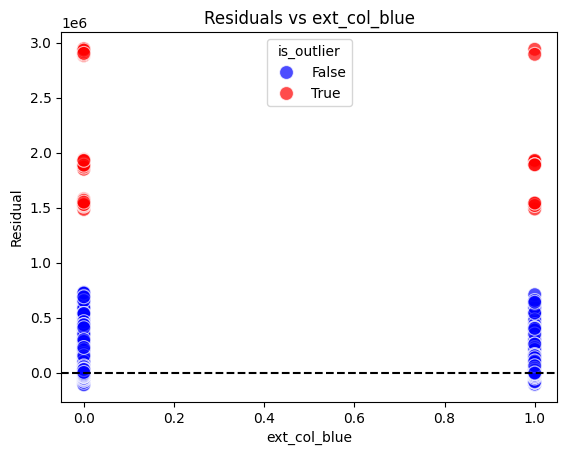

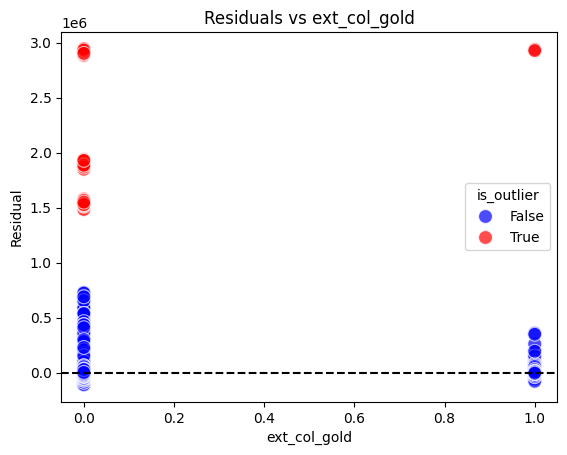

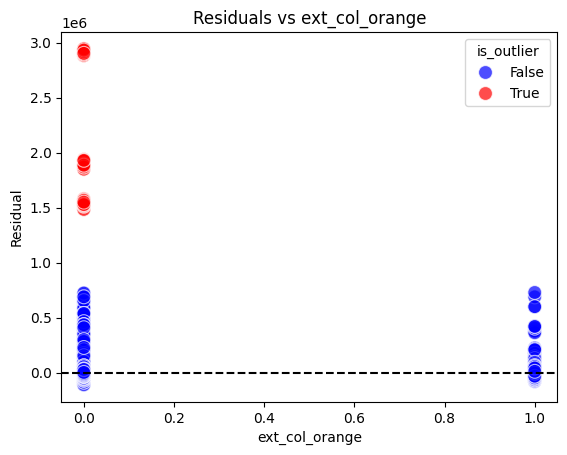

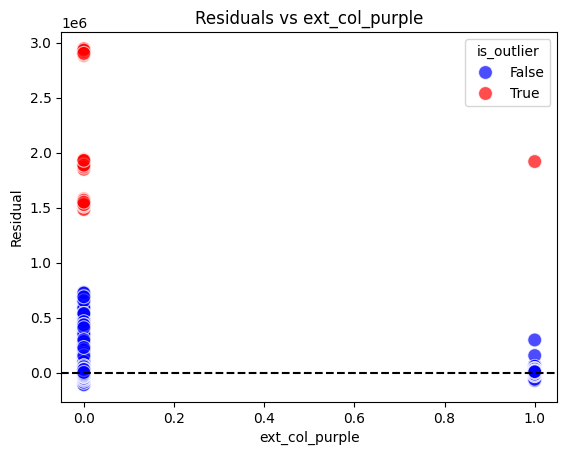

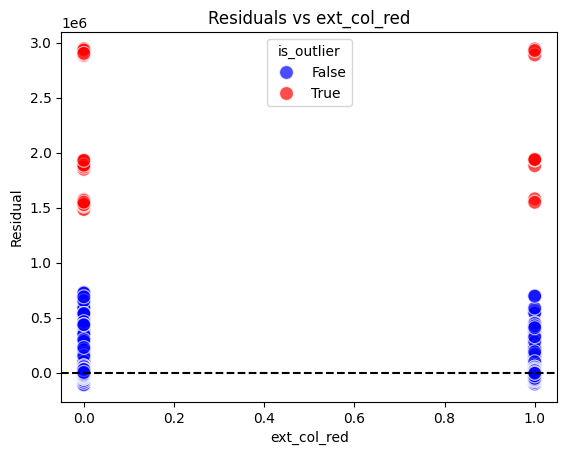

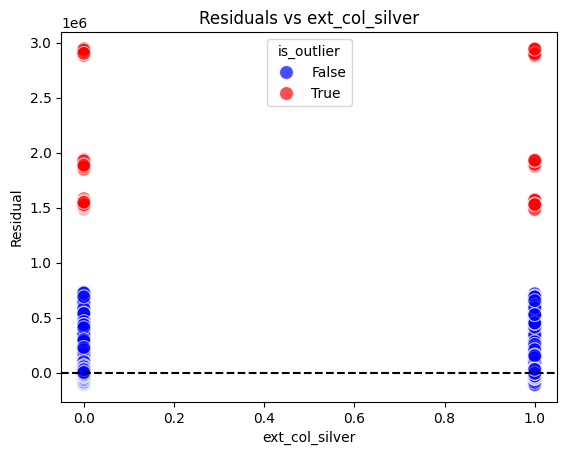

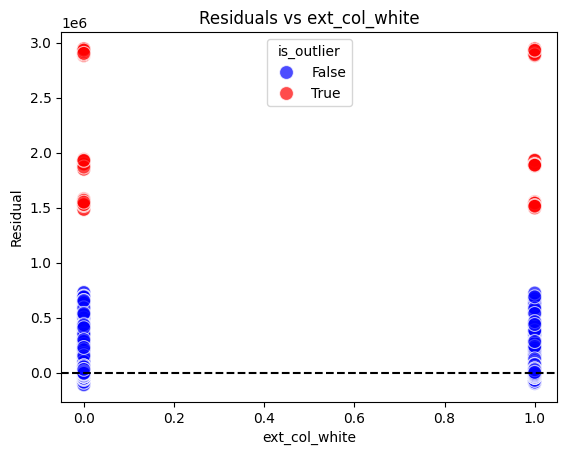

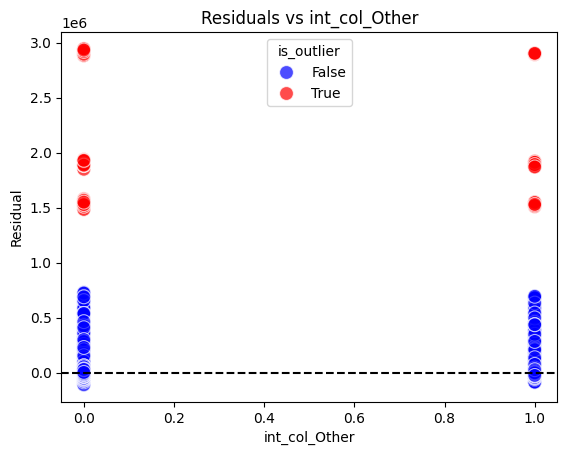

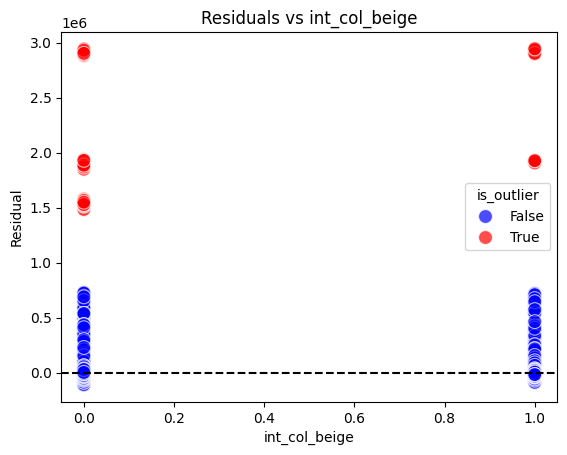

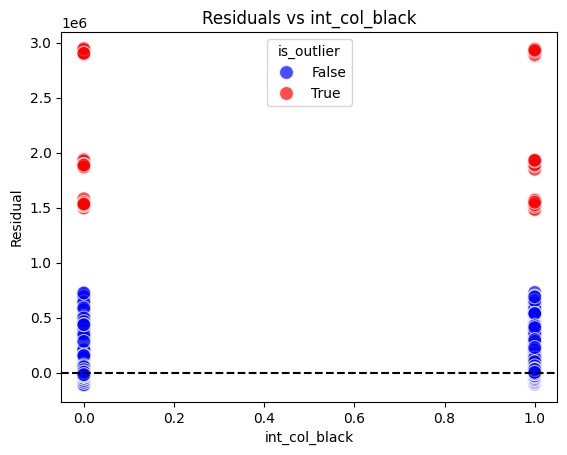

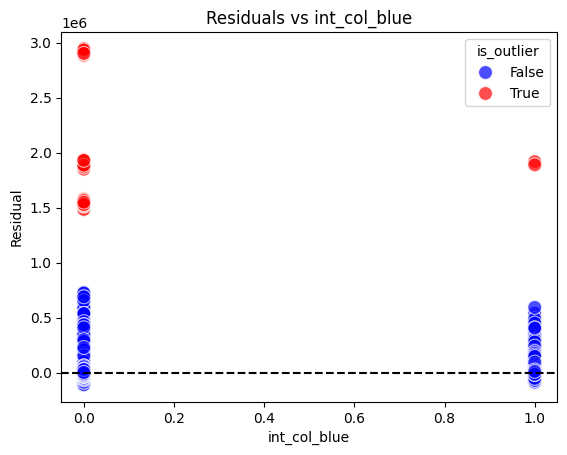

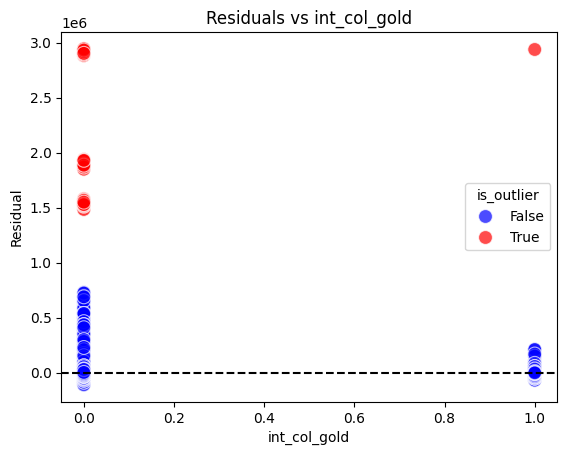

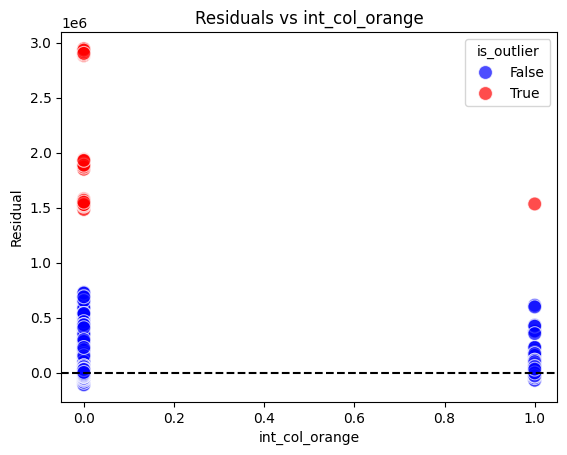

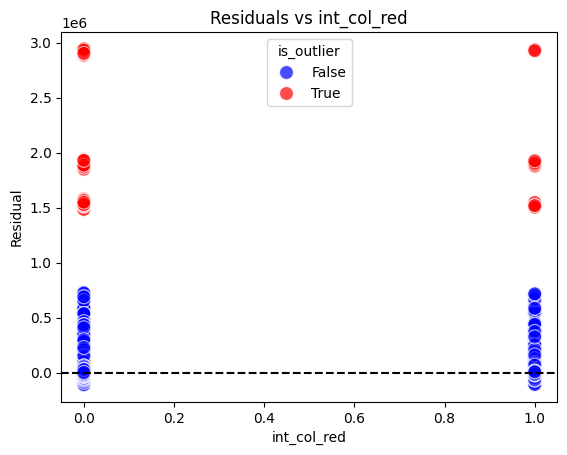

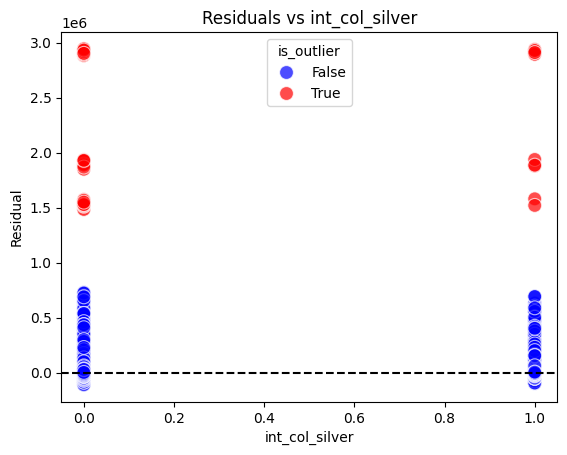

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


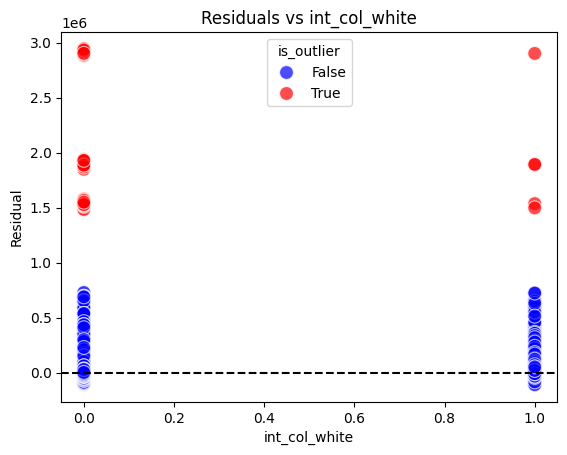

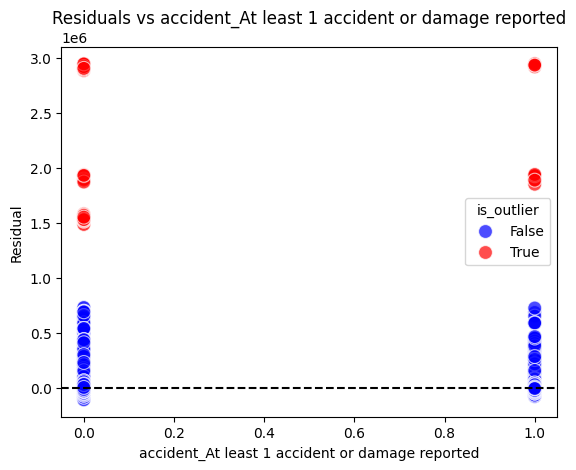

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


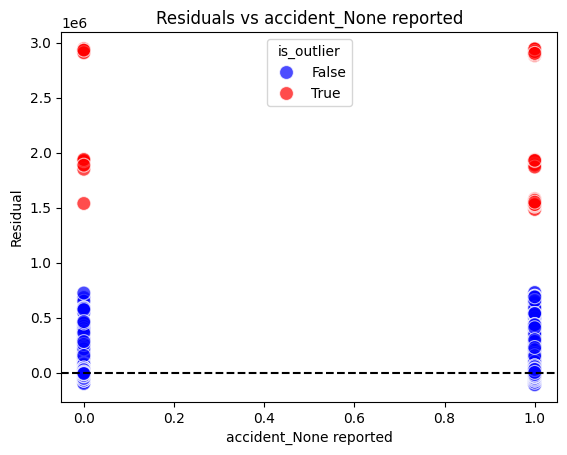

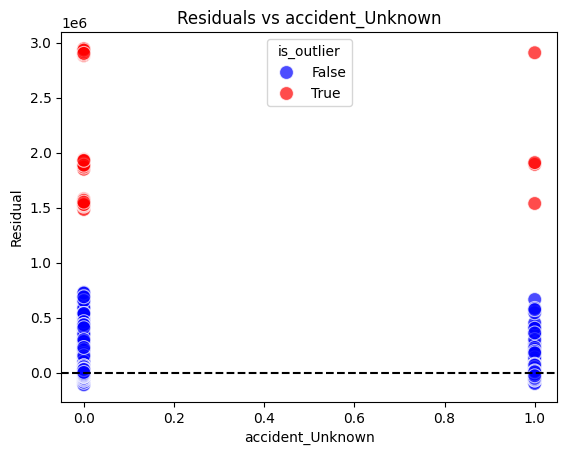

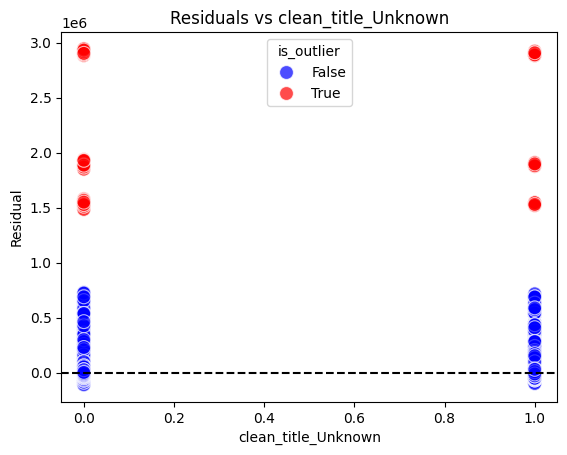

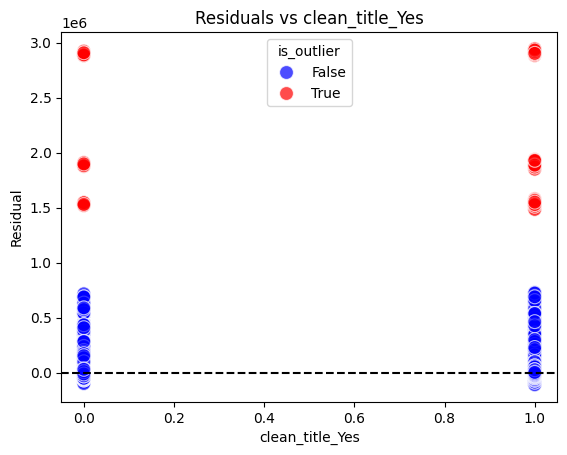

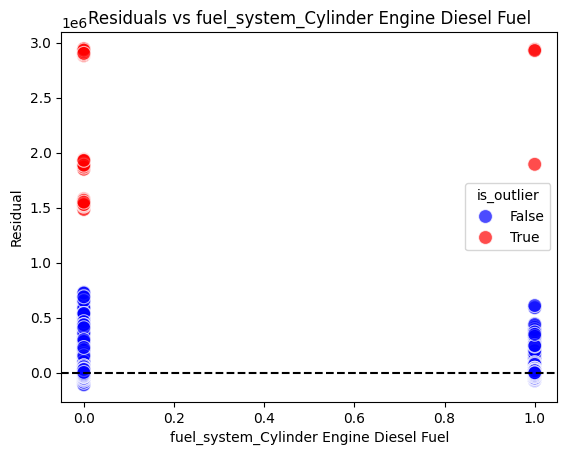

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


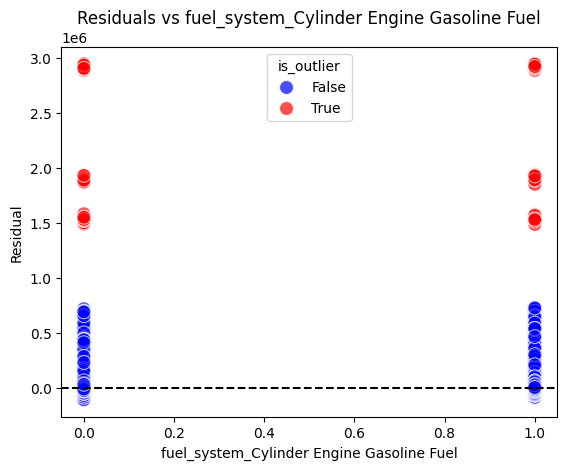

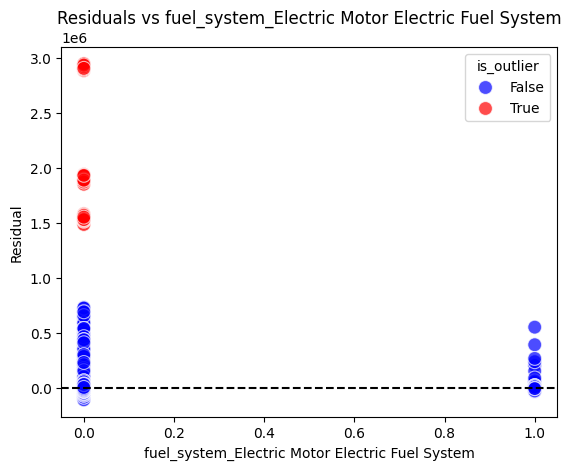

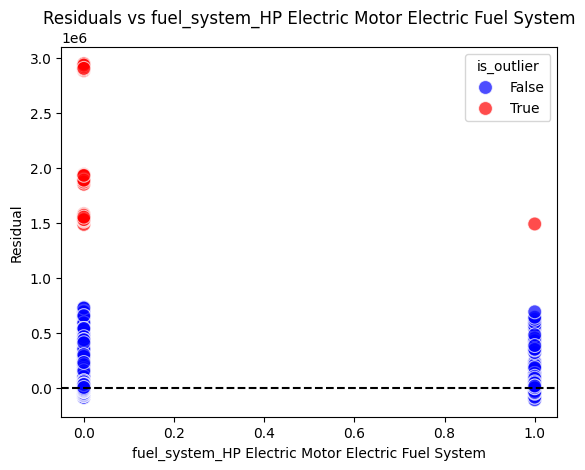

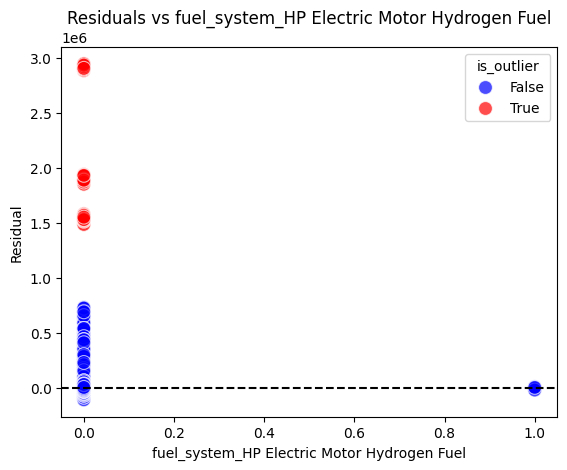

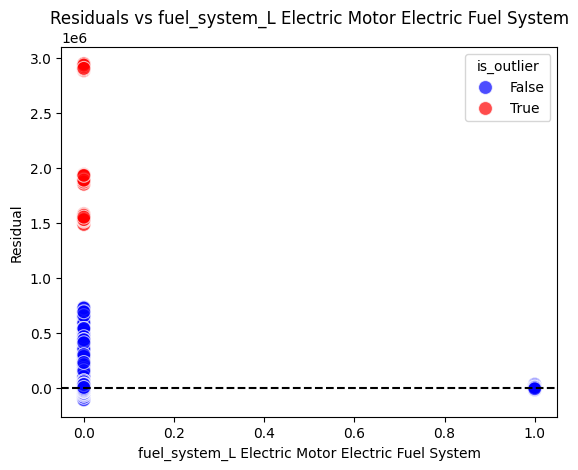

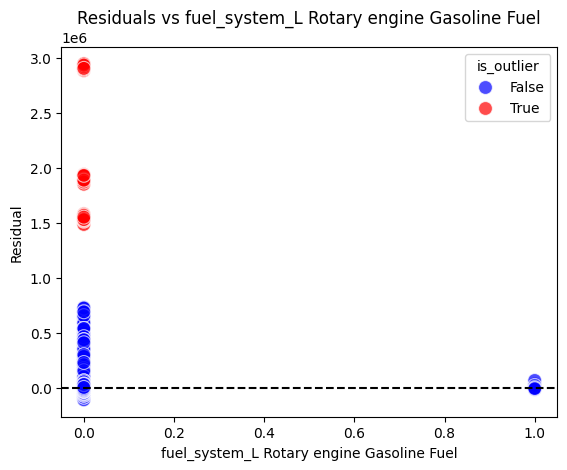

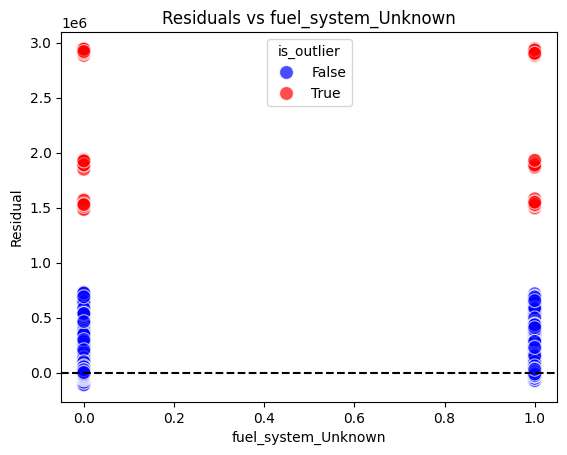

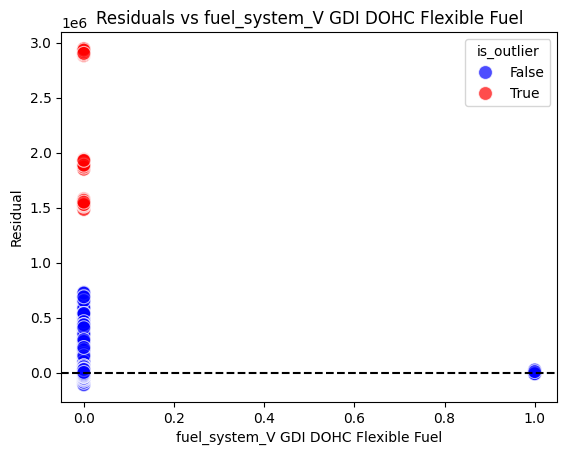

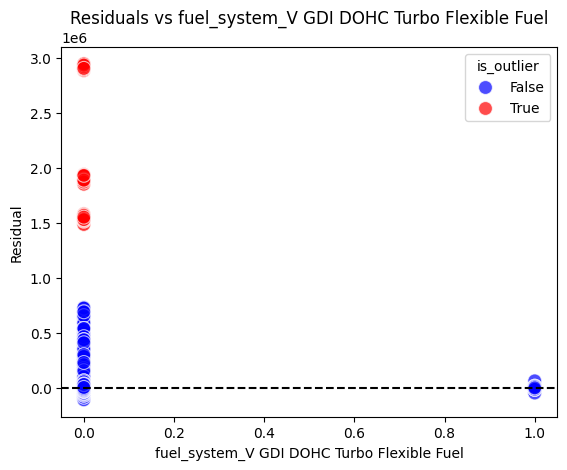

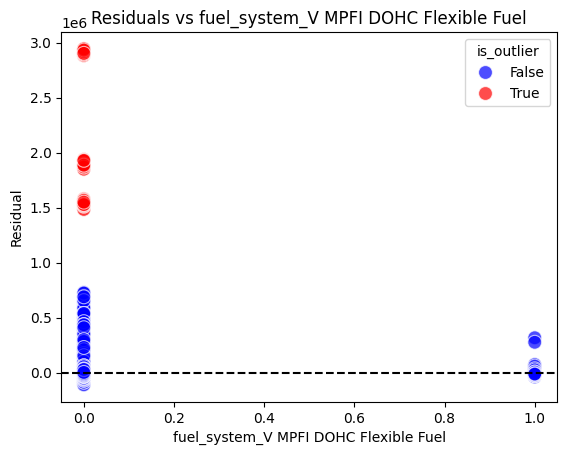

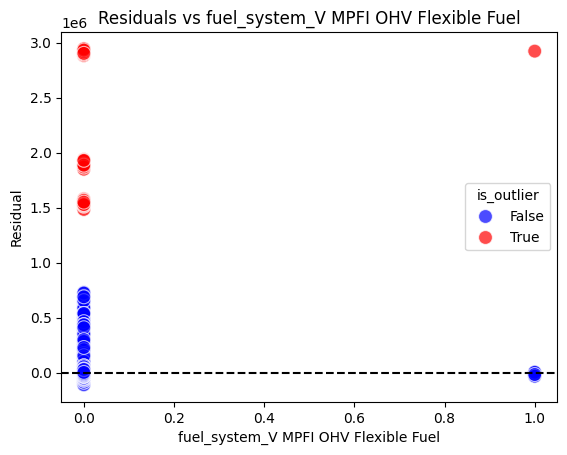

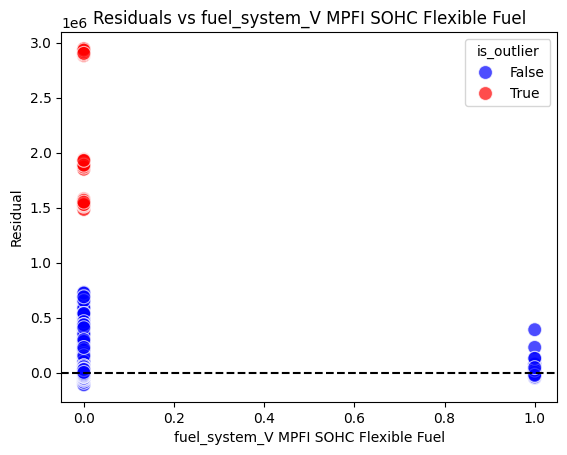

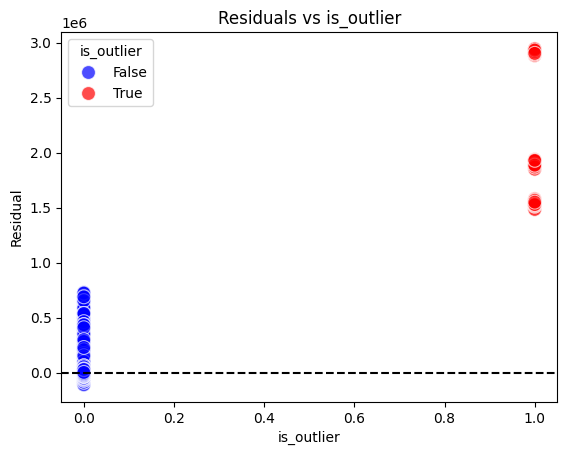

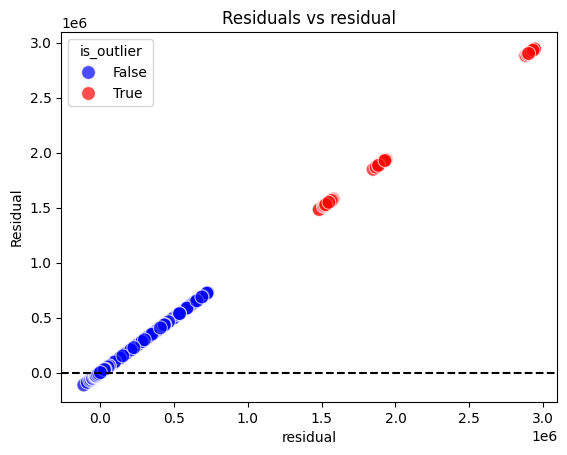

In [ ]:
plot_residuals_vs_features(X_train_clean, y_train, y_pred, X_train_clean.columns)

# Model Evaluation

In [ ]:
preds = {"Linear Regression": y_pred_OLS,
         "Lasso Regression": y_pred_lasso,
         "Ridge Regression": y_pred_ridge,
         "KNN Regression": y_pred_knn,
         "Decision Tree": y_pred_dt,
         "Adaboost":y_pred_ada}

In [ ]:
def evaluate_models(y_true, predictions: dict):
    """
    Evaluasi hasil prediksi dari beberapa model menggunakan RMSE.

    Parameters:
    -----------
    y_true : array-like
        Nilai sebenarnya (ground truth).
    predictions : dict
        Dictionary dengan format {"nama_model": y_pred}.

    Returns:
    --------
    DataFrame berisi RMSE tiap model.
    """
    results = []

    for model_name, y_pred in predictions.items():
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        results.append({"Model": model_name, "RMSE": rmse})

    return pd.DataFrame(results).sort_values(by="RMSE", ascending=True).reset_index(drop=True)

In [ ]:
result = evaluate_models(y_train, preds)

In [ ]:
result

## Residual Analysis

In [ ]:
# X_train_clean.columns

In [ ]:
# residuals = pd.Series(y.flatten() - y_pred.flatten(), index=y.index)
# for col  in X_train_clean.columns:
#   sns.scatterplot(data=X_train_clean, X=col, y = residuals )

# prediction

In [ ]:
X_test_clean = preprocessing_pipeline(df_test, imp, scaler, OHencoder)

In [ ]:
y_test_pred = knn.predict(X_test_clean)

In [ ]:
result_knn = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred})

In [ ]:
result_knn.to_csv("result_knn.csv", index=False)

In [ ]:
y_test_pred = dt_gridsearch.predict(X_test_clean)

In [ ]:
result_dt = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred})

In [ ]:
result_dt.to_csv("result_dt.csv", index=False)

In [ ]:
# def predict(model, data):
#   y_pred = model.predict(data)
#   result_df = pd.DataFrame({"id": data.index, "price": y_pred})
#   return result_df

In [ ]:
# y_test_pred1 = OLS_reg.predict(X_test_clean)

In [ ]:
# y_test_pred2 = Lasso_reg.predict(X_test_clean)

In [ ]:
# y_test_pred3 = lasso_cv.predict(X_test_clean)

In [ ]:
# result1 = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred1})
# result2 = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred2})
# result3 = pd.DataFrame({"id": X_test_clean.index, "price": y_test_pred3})

In [ ]:
# result1

In [ ]:
# result1.to_csv("result1.csv", index=False)
# result2.to_csv("result2.csv", index=False)
# result3.to_csv("result3.csv", index=False)

In [ ]:
# files.download("result1.csv")
# files.download("result2.csv")
# files.download("result3.csv")